## Cut convergence
The SetCut value is varied from 1 mm to 1 nm and the ratio of parent particles is tracked. Lowering the SetCut value will force the simulation to actually simulate more secondary particles thus chaging the way energy is deposited in the scintillator and changing the parent particle ratio's. Convergence seems to be achieved at 0.001 mm. 

In [6]:
"""
plot_cut_convergence.py
────────────────────────────────────────────────────────────────────────────────
Reads a set of scoring_cut<X>mm.root files produced by run_cut_sweep.sh and
plots convergence of:
  Parent-particle fractions vs production cut  (e-, mu+, other, …)
"""

import sys
import os
import glob
import re

import uproot
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ── Configuration ─────────────────────────────────────────────────────────────
FOLDER     = "cut_sweep"
PATTERN    = os.path.join(FOLDER, "scoring_cut*mm.root")
OUTPUT_PNG = os.path.join(FOLDER, "cut_convergence.png")

# Particles to give their own line; everything else → "other"
TRACKED_PARTICLES = {"mu-", "mu+", "e-", "e+", "proton", "pi-", "pi+"}

# ── Matplotlib style ───────────────────────────────────────────────────────────
"""
plt.rcParams.update({
    "figure.facecolor":  "#0e1117",
    "axes.facecolor":    "#161b22",
    "axes.edgecolor":    "#30363d",
    "axes.labelcolor":   "#e6edf3",
    "axes.titlecolor":   "#e6edf3",
    "axes.grid":         True,
    "grid.color":        "#21262d",
    "grid.linewidth":    0.8,
    "xtick.color":       "#8b949e",
    "ytick.color":       "#8b949e",
    "text.color":        "#e6edf3",
    "legend.facecolor":  "#161b22",
    "legend.edgecolor":  "#30363d",
    "font.family":       "monospace",
    "font.size":         10,
    "lines.linewidth":   2.0,
    "lines.markersize":  7,
})
"""
plt.rcParams.update({
    "figure.facecolor":  "#ffffff",   # white figure background
    "axes.facecolor":    "#f6f8fa",   # subtle light gray panel
    "axes.edgecolor":    "#d0d7de",   # soft border
    "axes.labelcolor":   "#24292f",   # dark text
    "axes.titlecolor":   "#24292f",
    "axes.grid":         True,
    "grid.color":        "#eaeef2",   # very light grid
    "grid.linewidth":    0.8,
    "xtick.color":       "#57606a",   # muted gray ticks
    "ytick.color":       "#57606a",
    "text.color":        "#24292f",
    "legend.facecolor":  "#f6f8fa",
    "legend.edgecolor":  "#d0d7de",
    "font.family":       "monospace",
    "font.size":         10,
    "lines.linewidth":   2.0,
    "lines.markersize":  7,
})
PALETTE = [
    "#58a6ff",  # blue
    "#f78166",  # red-orange
    "#3fb950",  # green
    "#d2a8ff",  # purple
    "#ffa657",  # amber
    "#79c0ff",  # sky
    "#ff7b72",  # salmon
    "#56d364",  # lime
]

# ── Helpers ────────────────────────────────────────────────────────────────────
def cut_from_filename(path):
    """Extract the cut value (float, mm) from filenames like scoring_cut0.001mm.root"""
    m = re.search(r"scoring_cut([0-9.e+-]+)mm\.root", os.path.basename(path))
    return float(m.group(1)) if m else None


def load_file(path):
    """Return a dict of arrays from one root file."""
    with uproot.open(path) as f:
        parentage = f["PhotonParentage"]
        parent_particle = parentage["ParentParticle"].array(library="np")
    return {"parent_particle": parent_particle}


def particle_fractions(parent_particle):
    """Return dict: particle_name → fraction (0-1)."""
    total = len(parent_particle)
    if total == 0:
        return {}
    counts = defaultdict(int)
    for p in parent_particle:
        key = p if p in TRACKED_PARTICLES else "other"
        counts[key] += 1
    return {k: v / total for k, v in counts.items()}


Found 6 file(s):
  cut_sweep/scoring_cut0.00001mm.root
  cut_sweep/scoring_cut0.0001mm.root
  cut_sweep/scoring_cut0.001mm.root
  cut_sweep/scoring_cut0.01mm.root
  cut_sweep/scoring_cut0.1mm.root
  cut_sweep/scoring_cut1.0mm.root

Saved: cut_sweep/cut_convergence.png


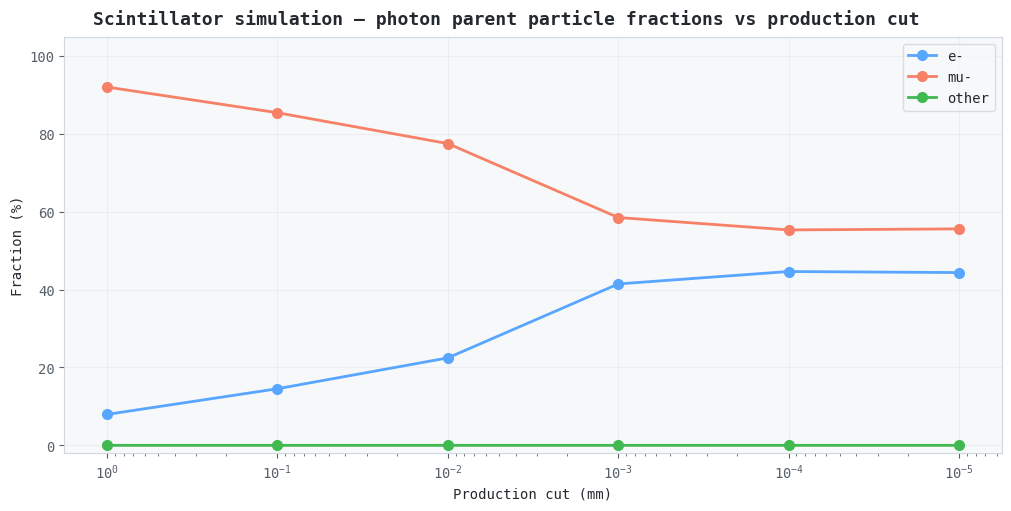

In [7]:
# ── Discover files ─────────────────────────────────────────────────────────────
files = sorted(glob.glob(PATTERN), key=lambda p: cut_from_filename(p) or 0)

if not files:
    print(f"No files matched pattern: {PATTERN}")
    print("Expected filenames like: scoring_cut0.001mm.root")
    sys.exit(1)

print(f"Found {len(files)} file(s):")
for f in files:
    print(f"  {f}")

# ── Collect data ───────────────────────────────────────────────────────────────
all_particle_keys = set()
rows = []   # list of (cut, data_dict)

for path in files:
    cut = cut_from_filename(path)
    if cut is None:
        print(f"  Skipping (can't parse cut): {path}")
        continue
    data = load_file(path)
    rows.append((cut, data))
    pf = particle_fractions(data["parent_particle"])
    all_particle_keys.update(pf.keys())

rows.sort(key=lambda x: x[0])
cuts = [r[0] for r in rows]
particle_keys = sorted(all_particle_keys)

particle_data = {k: [particle_fractions(r[1]["parent_particle"]).get(k, 0.0) for r in rows]
                 for k in particle_keys}

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
fig.suptitle("Scintillator simulation — photon parent particle fractions vs production cut",
             fontsize=13, fontweight="bold")

x = np.array(cuts)

for idx, key in enumerate(particle_keys):
    color = PALETTE[idx % len(PALETTE)]
    ax.plot(x, [v * 100 for v in particle_data[key]],
            "o-", color=color, label=key)

ax.set_xscale("log")
ax.set_xlabel("Production cut (mm)")
ax.set_ylabel("Fraction (%)")
ax.set_ylim(-2, 105)
ax.invert_xaxis()   # coarse on left, fine on right
ax.legend(loc="upper right")

# ── Save ───────────────────────────────────────────────────────────────────────
plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches="tight")
print(f"\nSaved: {OUTPUT_PNG}")
plt.show()

## Finnish evaluation
the parameters controlling the surface finish of the scintillator plate are varied to evaluate the photon yield, optimal settings will still have to be cross referenced with the real PMT output.

In [8]:
# ═══════════════════════════════════════════════════════════════════════════
# SURFACE SWEEP — imports, config, helpers
# ═══════════════════════════════════════════════════════════════════════════
import os, glob, re
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# ── Where the .root files live ────────────────────────────────────────────────
SWEEP_DIR = "surface_sweep"
PATTERN   = os.path.join(SWEEP_DIR,
                "scoring_finish*_refl*_sigma*_lobe*.root")

# ── Parameter grids (must match what the bash script used) ───────────────────
REFLECTIVITIES = [0.60, 0.70, 0.80, 0.85, 0.90, 0.95, 0.98, 0.99]
FINISHES       = ["groundbackpainted", "groundfrontpainted"]
SIGMAS         = [0.0, 0.1, 0.2, 0.3, 0.4]
LOBE_FRACS     = [0.0, 0.25, 0.5, 0.75, 1.0]

# ── Matplotlib dark theme ─────────────────────────────────────────────────────
"""
plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#e6edf3",
    "axes.titlecolor":  "#e6edf3",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#e6edf3",
    "font.family":      "monospace",
    "font.size":        9,
})
"""
# ── Filename parser ───────────────────────────────────────────────────────────
def parse_filename(path):
    """
    Returns (finish, refl, sigma, lobe) from a filename like
    scoring_finishgroundbackpainted_refl0.98_sigma0.1_lobe0.25.root
    Returns None if parsing fails.
    """
    bn = os.path.basename(path)
    m = re.match(
        r"scoring_finish(?P<finish>[^_]+)_refl(?P<refl>[0-9.]+)"
        r"_sigma(?P<sigma>[0-9.]+)_lobe(?P<lobe>[0-9.]+)\.root", bn)
    if not m:
        return None
    return (
        m.group('finish'),
        float(m.group('refl')),
        float(m.group('sigma')),
        float(m.group('lobe')),
    )

# ── Load mean detected photons per event ─────────────────────────────────────
def mean_hits(path):
    """Mean number of photon hits on the PMT cathode per event."""
    with uproot.open(path) as f:
        hits = f["PhotonHits"]
        ev_ids = hits["EvID"].array(library="np")
    if len(ev_ids) == 0:
        return 0.0
    # count hits per event, then average
    n_events = ev_ids.max() + 1
    counts = np.bincount(ev_ids, minlength=n_events)
    return float(counts.mean())

print('Helpers loaded.')


Helpers loaded.


In [9]:
# ── Load all files ────────────────────────────────────────────────────────────
files = glob.glob(PATTERN)
print(f'Found {len(files)} file(s) in {SWEEP_DIR}/')

# results[(finish, refl, sigma, lobe)] = mean_hits
results = {}
missing = []

for path in files:
    parsed = parse_filename(path)
    if parsed is None:
        print(f'  Could not parse: {path}')
        continue
    finish, refl, sigma, lobe = parsed
    results[(finish, refl, sigma, lobe)] = mean_hits(path)

# Report any missing combinations
for finish in FINISHES:
    for refl in REFLECTIVITIES:
        for sigma in SIGMAS:
            for lobe in LOBE_FRACS:
                key = (finish, refl, sigma, lobe)
                if key not in results:
                    missing.append(key)

print(f'Loaded {len(results)} results, {len(missing)} missing combinations.')
if missing:
    print('  Missing (first 5):', missing[:5])


Found 400 file(s) in surface_sweep/
Loaded 400 results, 0 missing combinations.


Saved: surface_sweep/surface_sweep_heatmap.png


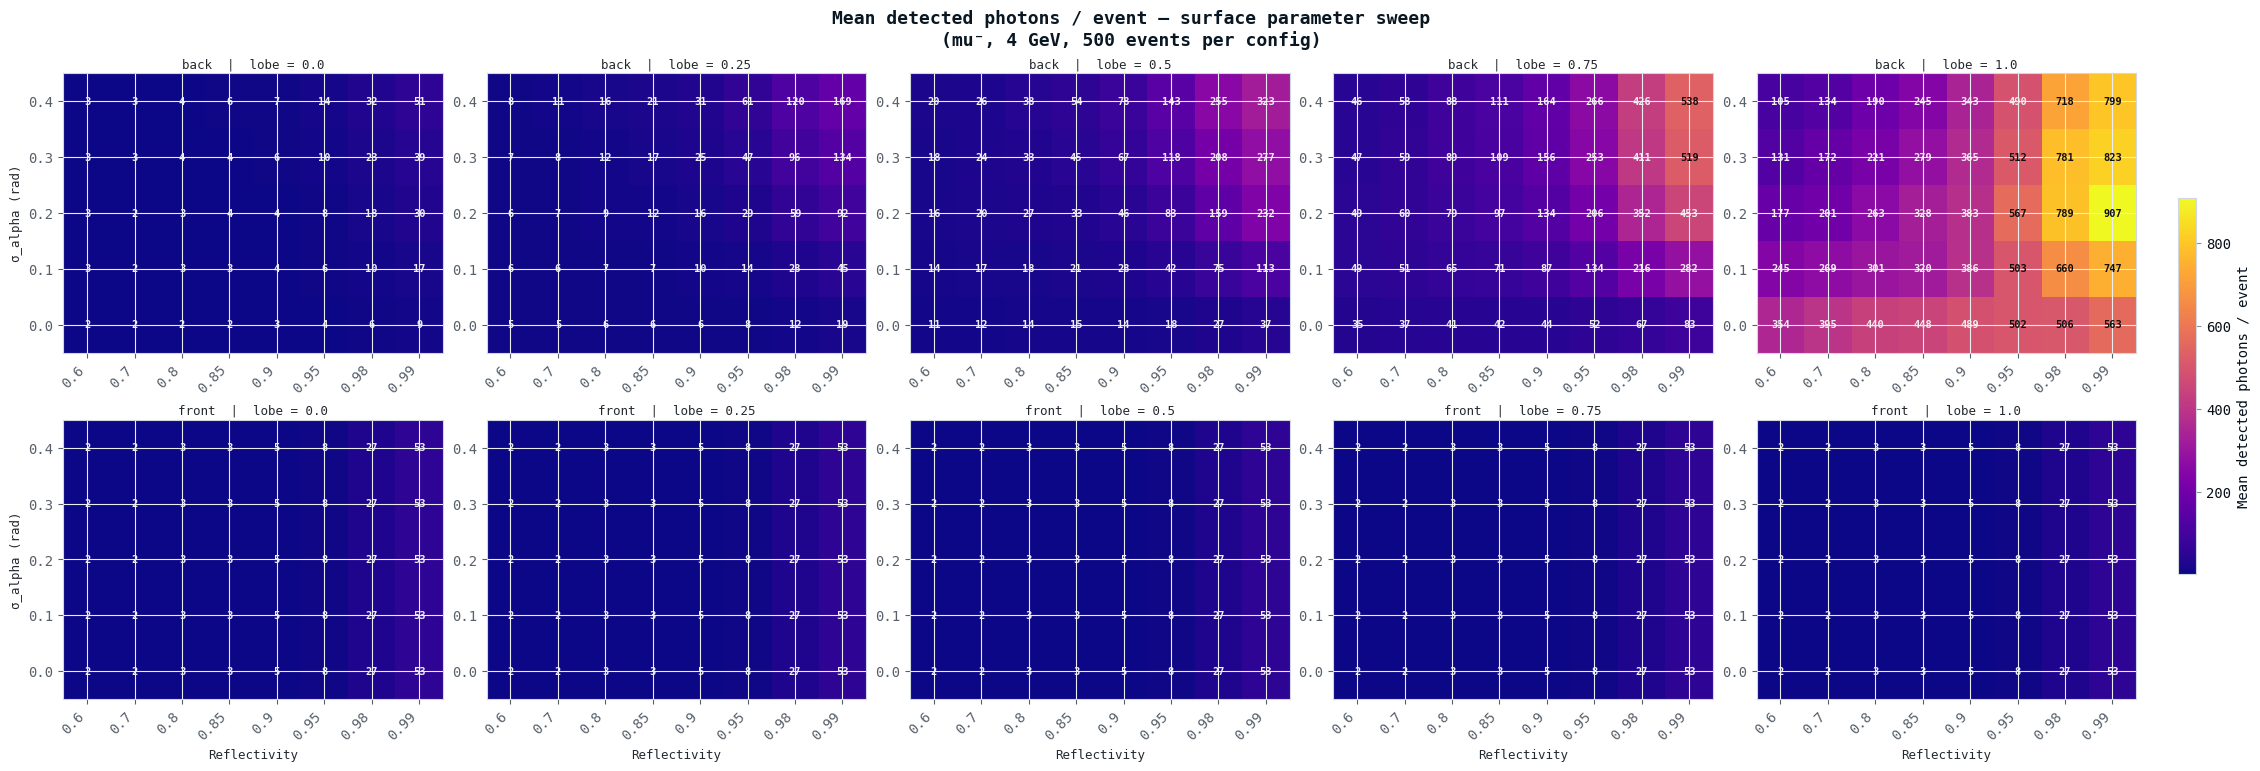

In [10]:
# ── Heatmap grid: rows=finish, cols=lobe_frac ─────────────────────────────────
# Each cell is a heatmap of reflectivity (x) vs sigma (y).
#
# Colour encodes mean detected photons/event — the key figure of merit.
# Higher = more light reaching the PMT = better surface.

N_FINISH = len(FINISHES)
N_LOBE   = len(LOBE_FRACS)

fig, axes = plt.subplots(
    N_FINISH, N_LOBE,
    figsize=(4.5 * N_LOBE, 3.8 * N_FINISH),
    constrained_layout=True,
)

fig.suptitle(
    "Mean detected photons / event — surface parameter sweep\n"
    "(mu⁻, 4 GeV, 500 events per config)",
    fontsize=13, fontweight='bold', color="#091722",
)

# Global colour scale across all sub-plots for fair comparison
all_vals = [
    results.get((finish, refl, sigma, lobe), np.nan)
    for finish in FINISHES
    for refl   in REFLECTIVITIES
    for sigma  in SIGMAS
    for lobe   in LOBE_FRACS
]
vmin = np.nanmin(all_vals)
vmax = np.nanmax(all_vals)

cmap = plt.cm.plasma   # perceptually uniform, works on dark backgrounds

for row, finish in enumerate(FINISHES):
    for col, lobe in enumerate(LOBE_FRACS):

        ax = axes[row][col] if N_FINISH > 1 else axes[col]

        # Build 2-D matrix:  rows = sigma (y-axis), cols = reflectivity (x-axis)
        Z = np.full((len(SIGMAS), len(REFLECTIVITIES)), np.nan)
        for si, sigma in enumerate(SIGMAS):
            for ri, refl in enumerate(REFLECTIVITIES):
                Z[si, ri] = results.get((finish, refl, sigma, lobe), np.nan)

        im = ax.imshow(
            Z,
            aspect='auto',
            origin='lower',
            cmap=cmap,
            vmin=vmin, vmax=vmax,
            interpolation='nearest',
        )

        # Annotate each cell with the numeric value
        for si in range(len(SIGMAS)):
            for ri in range(len(REFLECTIVITIES)):
                val = Z[si, ri]
                if not np.isnan(val):
                    # Choose text colour for contrast
                    norm_val = (val - vmin) / (vmax - vmin + 1e-9)
                    txt_color = '#111' if norm_val > 0.55 else '#eee'
                    ax.text(ri, si, f'{val:.0f}',
                            ha='center', va='center',
                            fontsize=7.5, color=txt_color, fontweight='bold')

        # Axes labels
        ax.set_xticks(range(len(REFLECTIVITIES)))
        ax.set_xticklabels([str(r) for r in REFLECTIVITIES], rotation=45, ha='right')
        ax.set_yticks(range(len(SIGMAS)))
        ax.set_yticklabels([str(s) for s in SIGMAS])

        if row == N_FINISH - 1:
            ax.set_xlabel('Reflectivity', fontsize=9)
        if col == 0:
            ax.set_ylabel('σ_alpha (rad)', fontsize=9)

        finish_label = finish.replace('ground', '').replace('painted', '')
        ax.set_title(f'{finish_label}  |  lobe = {lobe}', fontsize=9, pad=4)

# Shared colour bar
cbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=mcolors.Normalize(vmin=vmin, vmax=vmax), cmap=cmap),
    ax=axes, shrink=0.6, pad=0.02,
)
cbar.set_label('Mean detected photons / event', color="#03101c")
cbar.ax.yaxis.set_tick_params(color='#8b949e')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#080e15")

OUTPUT_PNG = os.path.join(SWEEP_DIR, 'surface_sweep_heatmap.png')
plt.savefig(OUTPUT_PNG, dpi=550, bbox_inches='tight')
print(f'Saved: {OUTPUT_PNG}')
plt.show()


Saved: surface_sweep/surface_sweep_heatmap.png
Saved: surface_sweep/surface_sweep_heatmap.pdf


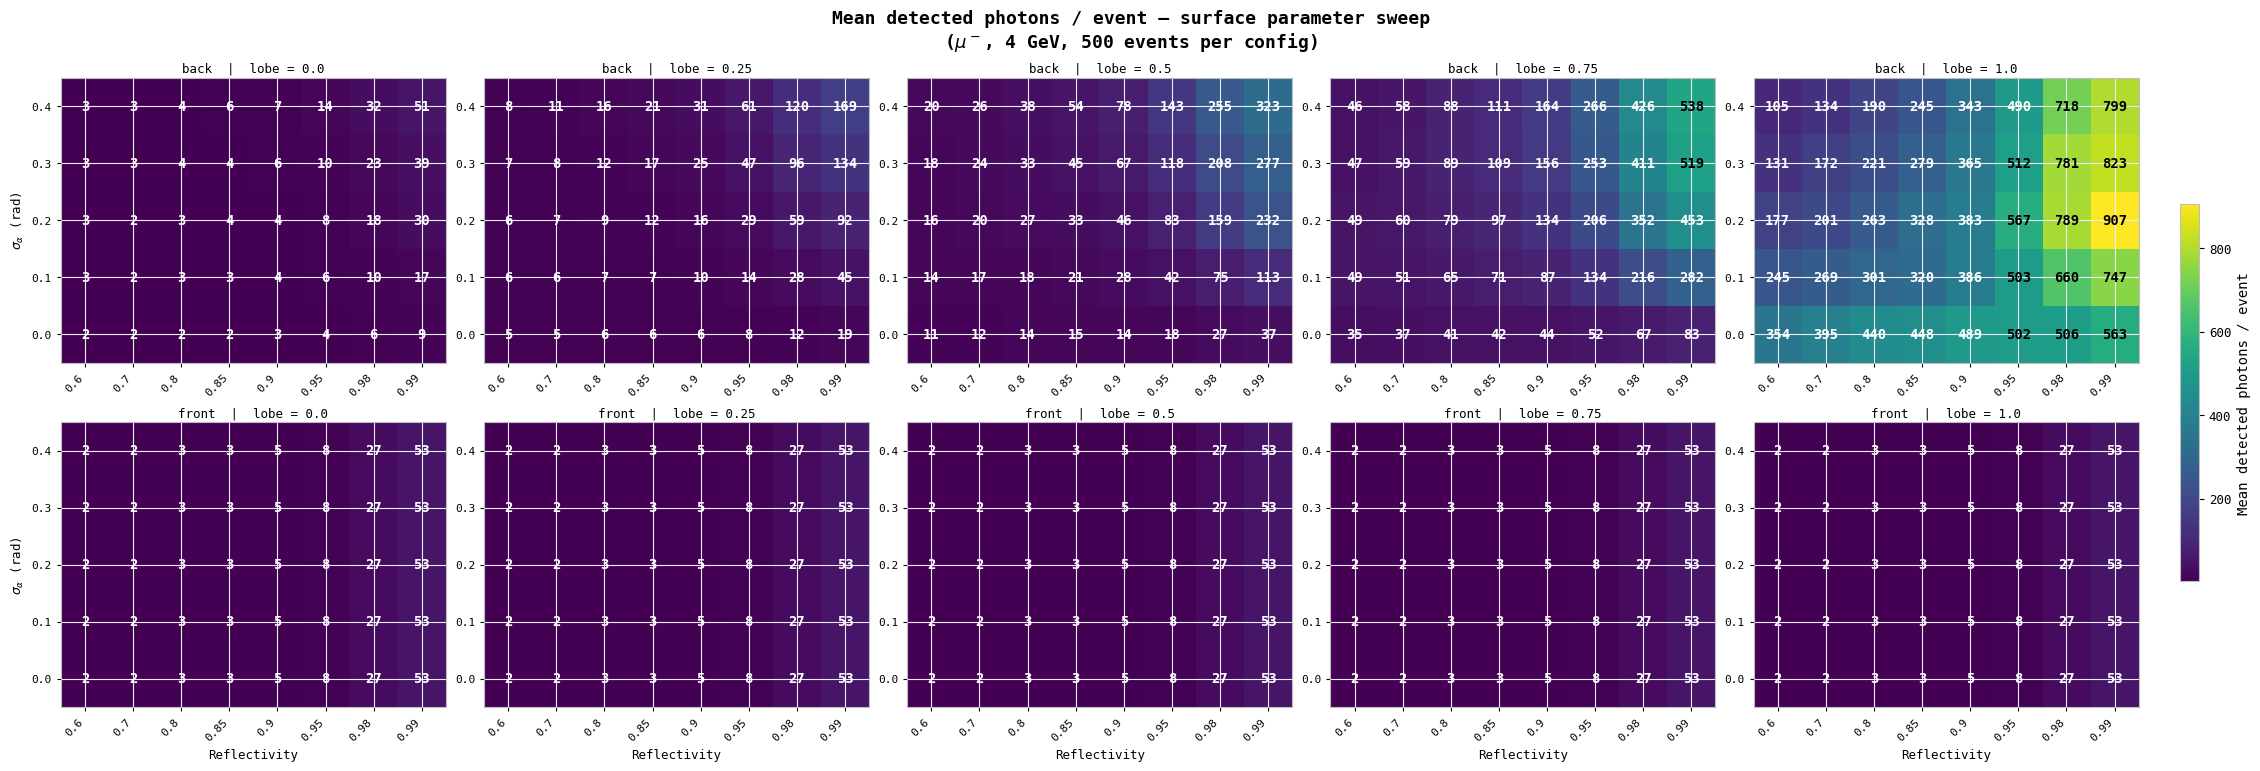

In [11]:
"""
Surface parameter sweep heatmap — white background, publication-ready.
Drop-in replacement. Assumes FINISHES, LOBE_FRACS, REFLECTIVITIES, SIGMAS,
results, np, plt, mcolors, os, SWEEP_DIR are already in scope.
"""

N_FINISH = len(FINISHES)
N_LOBE   = len(LOBE_FRACS)

fig, axes = plt.subplots(
    N_FINISH, N_LOBE,
    figsize=(4.5 * N_LOBE, 3.8 * N_FINISH),
    constrained_layout=True,
)
fig.patch.set_facecolor("white")

fig.suptitle(
    "Mean detected photons / event — surface parameter sweep\n"
    r"($\mu^-$, 4 GeV, 500 events per config)",
    fontsize=13, fontweight="bold", color="black",
)

# ── Global colour scale ────────────────────────────────────────────────────────
all_vals = [
    results.get((finish, refl, sigma, lobe), np.nan)
    for finish in FINISHES
    for refl   in REFLECTIVITIES
    for sigma  in SIGMAS
    for lobe   in LOBE_FRACS
]
vmin = np.nanmin(all_vals)
vmax = np.nanmax(all_vals)

# "viridis" is perceptually uniform AND prints well in greyscale.
# The mid-range (≈0.45–0.75) is a medium green — we switch text to black
# above that so contrast is always adequate on the light end,
# and white on the dark (purple) end.
cmap = plt.cm.viridis

for row, finish in enumerate(FINISHES):
    for col, lobe in enumerate(LOBE_FRACS):

        ax = axes[row][col] if N_FINISH > 1 else axes[col]
        ax.set_facecolor("white")

        # Build 2-D matrix: rows = sigma (y-axis), cols = reflectivity (x-axis)
        Z = np.full((len(SIGMAS), len(REFLECTIVITIES)), np.nan)
        for si, sigma in enumerate(SIGMAS):
            for ri, refl in enumerate(REFLECTIVITIES):
                Z[si, ri] = results.get((finish, refl, sigma, lobe), np.nan)

        im = ax.imshow(
            Z,
            aspect="auto",
            origin="lower",
            cmap=cmap,
            vmin=vmin, vmax=vmax,
            interpolation="nearest",
        )

        # ── Cell annotations ───────────────────────────────────────────────────
        # Use white text on dark cells (norm < 0.55), black on light cells.
        # Bold + slightly larger font so numbers are easy to read at full dpi.
        for si in range(len(SIGMAS)):
            for ri in range(len(REFLECTIVITIES)):
                val = Z[si, ri]
                if not np.isnan(val):
                    norm_val  = (val - vmin) / (vmax - vmin + 1e-9)
                    txt_color = "white" if norm_val < 0.55 else "black"
                    ax.text(
                        ri, si, f"{val:.0f}",
                        ha="center", va="center",
                        fontsize=10, fontweight="bold",
                        color=txt_color,
                    )

        # ── Tick labels ────────────────────────────────────────────────────────
        ax.set_xticks(range(len(REFLECTIVITIES)))
        ax.set_xticklabels(
            [str(r) for r in REFLECTIVITIES],
            rotation=45, ha="right", fontsize=8, color="black",
        )
        ax.set_yticks(range(len(SIGMAS)))
        ax.set_yticklabels([str(s) for s in SIGMAS], fontsize=8, color="black")

        for spine in ax.spines.values():
            spine.set_edgecolor("#BDBDBD")
            spine.set_linewidth(0.8)
        ax.tick_params(colors="black", length=3)

        if row == N_FINISH - 1:
            ax.set_xlabel("Reflectivity", fontsize=9, color="black")
        if col == 0:
            ax.set_ylabel(r"$\sigma_\alpha$ (rad)", fontsize=9, color="black")

        finish_label = finish.replace("ground", "").replace("painted", "")
        ax.set_title(
            f"{finish_label}  |  lobe = {lobe}",
            fontsize=9, pad=4, color="black",
        )

# ── Shared colour bar ──────────────────────────────────────────────────────────
cbar = fig.colorbar(
    plt.cm.ScalarMappable(
        norm=mcolors.Normalize(vmin=vmin, vmax=vmax), cmap=cmap
    ),
    ax=axes, shrink=0.6, pad=0.02,
)
cbar.set_label("Mean detected photons / event", color="black", fontsize=10)
cbar.ax.yaxis.set_tick_params(color="black", labelsize=9)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="black")
cbar.outline.set_edgecolor("#BDBDBD")

OUTPUT_PNG = os.path.join(SWEEP_DIR, "surface_sweep_heatmap.png")
OUTPUT_PDF = os.path.join(SWEEP_DIR, "surface_sweep_heatmap.pdf")
plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(OUTPUT_PDF, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Saved: {OUTPUT_PNG}")
print(f"Saved: {OUTPUT_PDF}")
plt.show()

In [12]:
# ── Top-10 configurations ranked by mean detected photons ────────────────────
import pandas as pd

rows_list = [
    {'finish': k[0], 'reflectivity': k[1], 'sigma': k[2],
     'lobe_frac': k[3], 'mean_hits': v}
    for k, v in results.items()
]
df = pd.DataFrame(rows_list).sort_values('mean_hits', ascending=False)
df.index = range(1, len(df) + 1)
print('Top 10 surface configurations by detected photon yield:')
print(df.head(10).to_string())


Top 10 surface configurations by detected photon yield:
               finish  reflectivity  sigma  lobe_frac  mean_hits
1   groundbackpainted          0.99    0.2        1.0     907.09
2   groundbackpainted          0.99    0.3        1.0     822.88
3   groundbackpainted          0.99    0.4        1.0     798.70
4   groundbackpainted          0.98    0.2        1.0     789.10
5   groundbackpainted          0.98    0.3        1.0     781.49
6   groundbackpainted          0.99    0.1        1.0     747.44
7   groundbackpainted          0.98    0.4        1.0     718.39
8   groundbackpainted          0.98    0.1        1.0     660.31
9   groundbackpainted          0.95    0.2        1.0     567.30
10  groundbackpainted          0.99    0.0        1.0     562.93


## Particle count evaluation
Simulations with different amount of particle events are performed to evaluate the convergence behavior of the simulations to balance accuracy and simulation time.

In [13]:
# ═══════════════════════════════════════════════════════════════════════════
# MUON COUNT SWEEP — imports, config, helpers
# ═══════════════════════════════════════════════════════════════════════════
import os, glob, re
import uproot
import numpy as np
import matplotlib.pyplot as plt

SWEEP_DIR = "muon_count_sweep"
PATTERN   = os.path.join(SWEEP_DIR, "scoring_n*.root")

MUON_COUNTS = [10, 20, 50, 100, 150, 200, 300, 500, 750, 1000, 2000, 5000, 10000, 20000]
"""
plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#e6edf3",
    "axes.titlecolor":  "#e6edf3",
    "axes.grid":        True,
    "grid.color":       "#21262d",
    "grid.linewidth":   0.8,
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#e6edf3",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "font.family":      "monospace",
    "font.size":        10,
    "lines.linewidth":  2.0,
    "lines.markersize": 7,
})
"""
def parse_filename(path):
    m = re.match(r"scoring_n(\d+)\.root", os.path.basename(path))
    return int(m.group(1)) if m else None

def load_hit_stats(path):
    """
    Returns (mean_hits, std_hits, sem_hits, n_events) for a single run.
    Uses the per-event hit count distribution — the natural within-run
    uncertainty that shrinks as sqrt(N) with more muons.
    """
    with uproot.open(path) as f:
        ev_hits   = f["PhotonHits"]["EvID"].array(library="np")
        ev_all    = f["PhotonsProduced"]["EvID"].array(library="np")
    n_events = int(ev_all.max()) + 1
    counts   = np.bincount(ev_hits, minlength=n_events).astype(float)
    mean = counts.mean()
    std  = counts.std(ddof=1)
    sem  = std / np.sqrt(n_events)
    return mean, std, sem, n_events

print('Helpers loaded.')


Helpers loaded.


In [14]:
# ── Load all files ────────────────────────────────────────────────────────────
files = {parse_filename(p): p
         for p in glob.glob(PATTERN)
         if parse_filename(p) is not None}

print(f'Found {len(files)} file(s)')

rows = []
for n in MUON_COUNTS:
    if n not in files:
        print(f'  Missing: n={n}')
        continue
    mean, std, sem, n_ev = load_hit_stats(files[n])
    rows.append({'n': n, 'mean': mean, 'std': std, 'sem': sem,
                 'cv_pct': 100 * std / mean})

print(f'\n{"N events":>10}  {"mean hits":>10}  {"std":>8}  '
      f'{"SEM":>8}  {"CV %":>8}')
print('-' * 55)
for r in rows:
    print(f'{r["n"]:>10}  {r["mean"]:>10.2f}  {r["std"]:>8.3f}  '
          f'{r["sem"]:>8.3f}  {r["cv_pct"]:>8.2f}')


Found 14 file(s)

  N events   mean hits       std       SEM      CV %
-------------------------------------------------------
        10      148.30    78.854    24.936     53.17
        20      139.55    75.088    16.790     53.81
        50      167.78   112.488    15.908     67.04
       100      159.12   102.296    10.230     64.29
       150      165.94   103.131     8.421     62.15
       200      160.52    97.233     6.875     60.57
       300      160.81   106.638     6.157     66.31
       500      158.28   102.430     4.581     64.71
       750      157.33    97.846     3.573     62.19
      1000      156.41    95.854     3.031     61.29
      2000      159.50    97.012     2.169     60.82
      5000      158.52    94.814     1.341     59.81
     10000      158.81    95.254     0.953     59.98
     20000      158.96    95.376     0.674     60.00


Saved: muon_count_sweep/muon_count_convergence.png


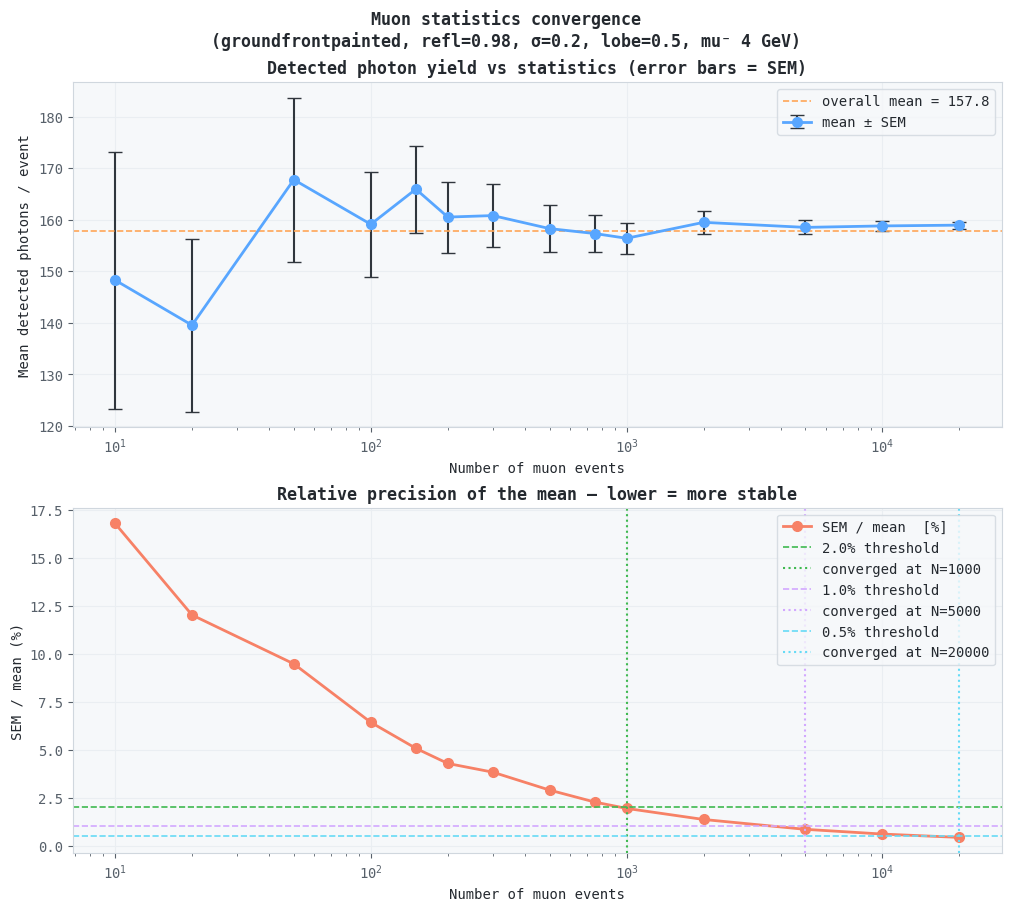

In [15]:
# ── Plot ─────────────────────────────────────────────────────────────────────
ns    = [r['n']      for r in rows]
means = [r['mean']   for r in rows]
sems  = [r['sem']    for r in rows]
cvs   = [r['cv_pct'] for r in rows]

fig, axes = plt.subplots(2, 1, figsize=(10, 9), constrained_layout=True)
fig.suptitle(
    "Muon statistics convergence\n"
    "(groundfrontpainted, refl=0.98, σ=0.2, lobe=0.5, mu⁻ 4 GeV)",
    fontsize=12, fontweight='bold',
)

# ── Panel 1: mean detected photons ± SEM ─────────────────────────────────────
# SEM = std / sqrt(N): the uncertainty on the *mean*, shrinks with more events.
# This directly shows how precisely we know the mean as N grows.
ax = axes[0]
ax.errorbar(ns, means, yerr=sems,
            fmt='o-', color='#58a6ff', ecolor='#30363d',
            elinewidth=1.5, capsize=5, label='mean ± SEM')
grand_mean = np.mean(means)
ax.axhline(grand_mean, color='#ffa657', linestyle='--', linewidth=1.2,
           label=f'overall mean = {grand_mean:.1f}')
ax.set_xscale('log')
ax.set_xlabel('Number of muon events')
ax.set_ylabel('Mean detected photons / event')
ax.set_title('Detected photon yield vs statistics (error bars = SEM)',
             fontweight='bold')
ax.legend()

# ── Panel 2: SEM as % of mean — shows when the estimate has converged ─────────
# Equivalent to CV/sqrt(N): once this is below ~1-2% further muons add little.
ax = axes[1]
sem_pct = [100 * s / m for s, m in zip(sems, means)]
ax.plot(ns, sem_pct, 'o-', color='#f78166', label='SEM / mean  [%]')
for threshold, color in [(2.0, '#3fb950'), (1.0, '#d2a8ff'), (0.5, "#66dbf6")]:
    ax.axhline(threshold, color=color, linestyle='--', linewidth=1.2,
               label=f'{threshold}% threshold')
    conv = next((n for n, p in zip(ns, sem_pct) if p < threshold), None)
    if conv:
        ax.axvline(conv, color=color, linestyle=':', linewidth=1.5,
                   label=f'converged at N={conv}')
ax.set_xscale('log')
ax.set_xlabel('Number of muon events')
ax.set_ylabel('SEM / mean (%)')
ax.set_title('Relative precision of the mean — lower = more stable',
             fontweight='bold')
ax.legend(loc='upper right')

OUTPUT_PNG = os.path.join(SWEEP_DIR, 'muon_count_convergence.png')
plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches='tight')
print(f'Saved: {OUTPUT_PNG}')
plt.show()


## Energy look up table
An energy look up table is constructed that shows the photon yield for each energy value

In [16]:
# ═══════════════════════════════════════════════════════════════════════════
# ENERGY SWEEP — imports, config, helpers
# ═══════════════════════════════════════════════════════════════════════════
import os, glob, re
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

SWEEP_DIR = "energy_sweep_e-_1MeV_to_1GeV"
PATTERN   = os.path.join(SWEEP_DIR, "scoring_e*MeV.root")
"""
plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#e6edf3",
    "axes.titlecolor":  "#e6edf3",
    "axes.grid":        True,
    "grid.color":       "#21262d",
    "grid.linewidth":   0.8,
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#e6edf3",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "font.family":      "monospace",
    "font.size":        10,
    "lines.linewidth":  2.0,
    "lines.markersize": 0,
})
"""
def parse_energy(path):
    """Extract energy in MeV from filename like scoring_e123p4567MeV.root"""
    m = re.match(r"scoring_e([0-9p]+)MeV\.root", os.path.basename(path))
    if not m:
        return None
    return float(m.group(1).replace('p', '.'))

def load_yield(path):
    """
    Returns (mean_produced, sem_produced, mean_hits, sem_hits, n_events).
    produced = scintillation photons created in scintillator.
    hits     = optical photons that reached the PMT cathode.
    """
    with uproot.open(path) as f:
        prod_n  = f["PhotonsProduced"]["n_produced"].array(library="np").astype(float)
        hit_ev  = f["PhotonHits"]["EvID"].array(library="np")
        prod_ev = f["PhotonsProduced"]["EvID"].array(library="np")
    n_events  = len(prod_n)
    hit_counts = np.bincount(hit_ev, minlength=n_events).astype(float)
    mean_prod = prod_n.mean()
    sem_prod  = prod_n.std(ddof=1) / np.sqrt(n_events)
    mean_hits = hit_counts.mean()
    sem_hits  = hit_counts.std(ddof=1) / np.sqrt(n_events)
    return mean_prod, sem_prod, mean_hits, sem_hits, n_events

print('Helpers loaded.')

Helpers loaded.


In [17]:
# ── Load all files ────────────────────────────────────────────────────────────
files = glob.glob(PATTERN)
print(f'Found {len(files)} file(s) in {SWEEP_DIR}/')

rows = []
for path in files:
    e = parse_energy(path)
    if e is None:
        print(f'  Could not parse: {path}')
        continue
    mp, sp, mh, sh, n = load_yield(path)
    rows.append({'energy_MeV': e,
                 'mean_produced': mp, 'sem_produced': sp,
                 'mean_hits':     mh, 'sem_hits':     sh,
                 'n_events': n})

rows.sort(key=lambda r: r['energy_MeV'])
print(f'Loaded {len(rows)} energy points.')

# Arrays for plotting
E        = np.array([r['energy_MeV']   for r in rows])
produced = np.array([r['mean_produced'] for r in rows])
prod_err = np.array([r['sem_produced']  for r in rows])
hits     = np.array([r['mean_hits']     for r in rows])
hits_err = np.array([r['sem_hits']      for r in rows])
# Detection efficiency: fraction of produced photons that reach the PMT
eff      = np.where(produced > 0, hits / produced * 100, np.nan)


Found 100 file(s) in energy_sweep_e-_1MeV_to_1GeV/
Loaded 100 energy points.


Saved: energy_sweep_e-_1MeV_to_1GeV/energy_yield_curve.png


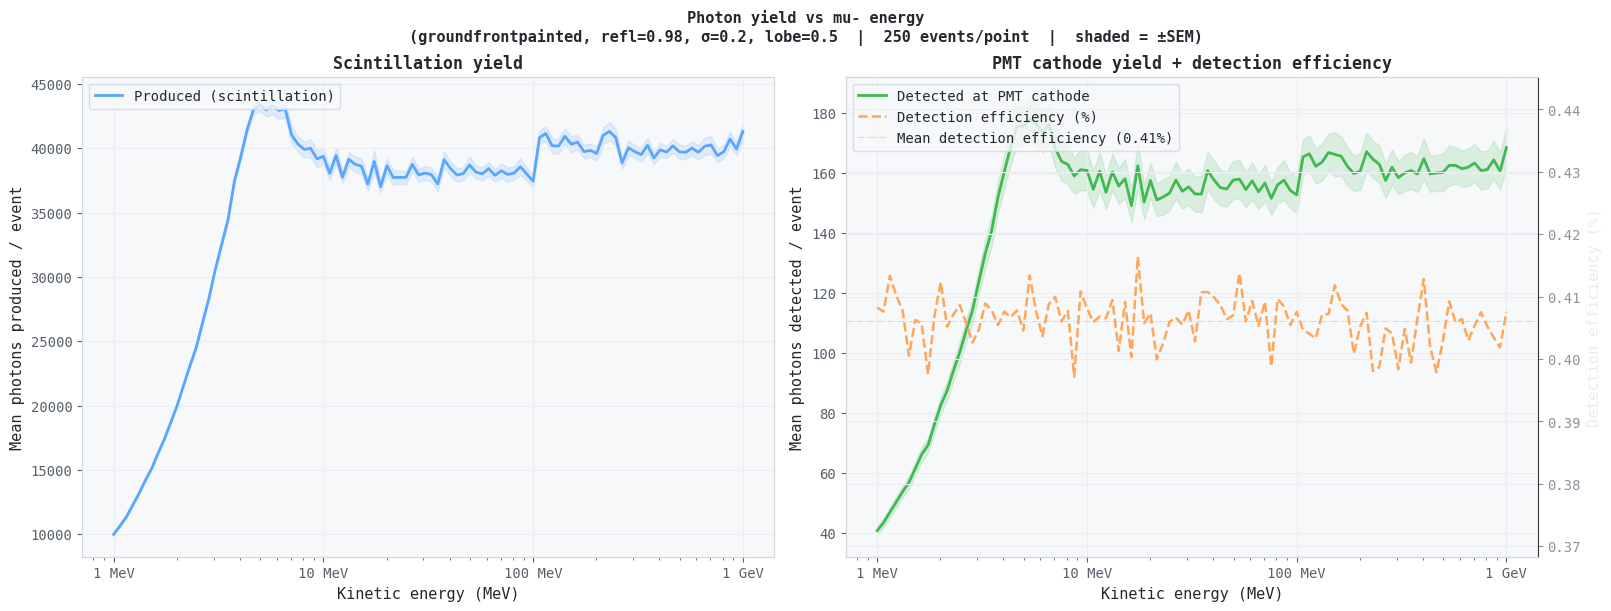

In [18]:
# ── Yield curve: two panels ───────────────────────────────────────────────────
col_prod = '#58a6ff'   # blue  — produced
col_hits = '#3fb950'   # green — detected
col_eff  = '#ffa657'   # amber — efficiency

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
fig.suptitle(
    'Photon yield vs mu- energy\n'
    '(groundfrontpainted, refl=0.98, σ=0.2, lobe=0.5  |  '
    f'{rows[0]["n_events"]} events/point  |  shaded = ±SEM)',
    fontsize=11, fontweight='bold',
)

def style_twinx(ax):
    ax.spines['right'].set_color('#30363d')
    ax.tick_params(colors='#8b949e')
    ax.yaxis.label.set_color('#e6edf3')

def format_energy_axis(ax):
    ax.set_xscale('log')
    ax.set_xlabel('Kinetic energy (MeV)', fontsize=11)
    ax.xaxis.set_major_formatter(
        ticker.FuncFormatter(
            lambda x, _: (f'{x/1000:.0f} GeV' if x >= 1000
                          else f'{x:.0f} MeV')))

# ── Panel 1: produced photons only ───────────────────────────────────────────
ax1.fill_between(E, produced - prod_err, produced + prod_err,
                 color=col_prod, alpha=0.15)
ax1.plot(E, produced, color=col_prod, linewidth=2,
         label='Produced (scintillation)')
ax1.set_ylabel('Mean photons produced / event', fontsize=11)
ax1.legend(loc='upper left', fontsize=10)
ax1.set_title('Scintillation yield', fontweight='bold')
format_energy_axis(ax1)

# ── Panel 2: detected photons + efficiency ────────────────────────────────────
ax2_eff = ax2.twinx()
style_twinx(ax2_eff)

ax2.fill_between(E, hits - hits_err, hits + hits_err,
                 color=col_hits, alpha=0.15)
ax2.plot(E, hits, color=col_hits, linewidth=2,
         label='Detected at PMT cathode')
ax2.set_ylabel('Mean photons detected / event', fontsize=11)
format_energy_axis(ax2)
ax2.set_title('PMT cathode yield + detection efficiency', fontweight='bold')

ax2_eff.plot(E, eff, color=col_eff, linewidth=1.8, linestyle='--',
             label='Detection efficiency (%)')
ax2_eff.axhline(np.mean(eff), color=col_eff, linestyle='-.', linewidth=0.7, alpha=0.5,
                          label=f'Mean detection efficiency ({np.mean(eff):.2f}%)')
ax2_eff.set_ylabel('Detection efficiency (%)', fontsize=11)

# Tight scale: pad 150% above and below the actual data range
eff_valid = eff[np.isfinite(eff)]
eff_margin = (eff_valid.max() - eff_valid.min()) * 1.50
ax2_eff.set_ylim(eff_valid.min() - eff_margin,
                 eff_valid.max() + eff_margin)

lines3, labels3 = ax2.get_legend_handles_labels()
lines4, labels4 = ax2_eff.get_legend_handles_labels()
ax2.legend(lines3 + lines4, labels3 + labels4, loc='upper left', fontsize=10)

OUTPUT_PNG = os.path.join(SWEEP_DIR, 'energy_yield_curve.png')
plt.savefig(OUTPUT_PNG, dpi=150, bbox_inches='tight')
print(f'Saved: {OUTPUT_PNG}')
plt.show()

In [19]:
# ═══════════════════════════════════════════════════════════════════════════
# PMT RESPONSE — imports + configurable parameters
# ═══════════════════════════════════════════════════════════════════════════
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from scipy.constants import h, c, e as e_charge
"""
plt.rcParams.update({
    "figure.facecolor": "#0e1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#e6edf3",
    "axes.titlecolor":  "#e6edf3",
    "axes.grid":        True,
    "grid.color":       "#21262d",
    "grid.linewidth":   0.8,
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#e6edf3",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
    "font.family":      "monospace",
    "font.size":        10,
})
"""
# ────────────────────────────────────────────────────────────────────────────
# ★  EDIT THESE TO MATCH YOUR PMT  ★
# ────────────────────────────────────────────────────────────────────────────

# QE curve: (wavelength_nm, QE_fraction) pairs.
# Default: Hamamatsu R7724 bialkali cathode — typical for plastic scintillator.
# Replace with your own PMT's datasheet values.
QE_CURVE_NM = np.array([
    270, 300, 320, 340, 360, 380, 400, 420, 440,
    460, 480, 500, 520, 540, 560, 580, 600, 620,
])
QE_CURVE_FRAC = np.array([
    0.002, 0.055, 0.120, 0.195, 0.245, 0.265, 0.260, 0.240, 0.210,
    0.175, 0.140, 0.100, 0.065, 0.038, 0.018, 0.007, 0.002, 0.000,
])

# SPE pulse shape: modelled as a difference of two exponentials
#   I(t) = A * (exp(-t/tau_decay) - exp(-t/tau_rise))   for t >= 0
# Tune these to your PMT's transit-time / pulse-width spec.
SPE_TAU_RISE_NS  = 1.5    # ns — fast rising edge (dynode transit time spread)
SPE_TAU_DECAY_NS = 5.0    # ns — slower falling edge (anode RC + dynode chain)

# Gain: number of electrons per photoelectron (sets pulse amplitude scale)
PMT_GAIN = 1e6            # typical bialkali PMT

# Timing window for the pulse waveform (ns)
T_START_NS  = -20.0
T_END_NS    = 200.0
T_BIN_NS    =   0.5   # time resolution of the simulated waveform

# ────────────────────────────────────────────────────────────────────────────

print('PMT parameters loaded.')
print(f'  QE curve:   {len(QE_CURVE_NM)} wavelength points '
      f'({QE_CURVE_NM[0]}–{QE_CURVE_NM[-1]} nm)')
print(f'  SPE shape:  rise={SPE_TAU_RISE_NS} ns  decay={SPE_TAU_DECAY_NS} ns')
print(f'  PMT gain:   {PMT_GAIN:.1e}')


PMT parameters loaded.
  QE curve:   18 wavelength points (270–620 nm)
  SPE shape:  rise=1.5 ns  decay=5.0 ns
  PMT gain:   1.0e+06


Helper functions defined.
  Waveform window: -20.0 → 200.0 ns  (440 bins @ 0.5 ns)


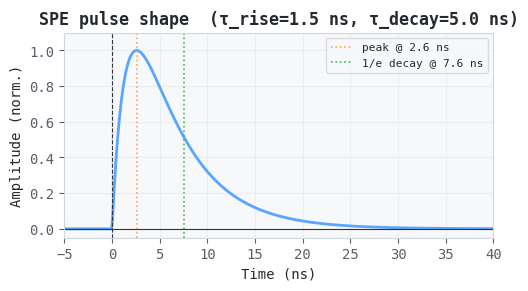

In [20]:
# ── Helper functions ─────────────────────────────────────────────────────────

# Interpolated QE function (clamps to 0 outside the defined range)
_qe_interp = interp1d(
    QE_CURVE_NM, QE_CURVE_FRAC,
    kind='linear', bounds_error=False, fill_value=0.0,
)

def photon_energy_MeV_to_wavelength_nm(energy_MeV):
    energy_J = energy_MeV * 1e6 * e_charge   # MeV → eV → J
    wavelength_m = (h * c) / energy_J
    return wavelength_m * 1e9

def apply_qe(wavelengths_nm, rng=None):
    """
    Stochastic QE filter.
    Returns boolean mask: True where a photoelectron is emitted.
    """
    if rng is None:
        rng = np.random.default_rng()
    qe = _qe_interp(wavelengths_nm)
    return rng.random(len(wavelengths_nm)) < qe

def spe_pulse(t_ns):
    """
    Single-photoelectron current pulse shape (arbitrary units, peak ≈ 1).
    I(t) = A*(exp(-t/tau_d) - exp(-t/tau_r))  for t >= 0, else 0.
    Normalised so the peak value is 1.
    """
    t = np.asarray(t_ns, dtype=float)
    pulse = np.where(
        t >= 0,
        np.exp(-t / SPE_TAU_DECAY_NS) - np.exp(-t / SPE_TAU_RISE_NS),
        0.0,
    )
    peak = pulse.max()
    return pulse / peak if peak > 0 else pulse

def build_waveform(pe_times_ns, t_bins):
    """
    Convolve a list of photoelectron arrival times with the SPE pulse shape
    to produce the total PMT anode current waveform.

    pe_times_ns : array of photoelectron arrival times [ns]
    t_bins      : 1-D array of time bin centres [ns]
    Returns     : current waveform in units of (electrons / ns) * PMT_GAIN
    """
    dt = t_bins[1] - t_bins[0]
    waveform = np.zeros(len(t_bins))
    spe_t    = t_bins - t_bins[0]           # pulse kernel starting at 0
    spe_k    = spe_pulse(spe_t)             # shape kernel

    for t_pe in pe_times_ns:
        idx = np.searchsorted(t_bins, t_pe)
        if 0 <= idx < len(t_bins):
            # Shift the SPE kernel to start at idx
            end = min(idx + len(spe_k), len(waveform))
            seg_len = end - idx
            waveform[idx:end] += spe_k[:seg_len]

    # Scale to physical current: PMT_GAIN electrons per pe, dt converts to charge
    return waveform * PMT_GAIN

# Pre-build the time axis once
T_BINS = np.arange(T_START_NS, T_END_NS, T_BIN_NS)

print('Helper functions defined.')
print(f'  Waveform window: {T_START_NS} → {T_END_NS} ns  ({len(T_BINS)} bins @ {T_BIN_NS} ns)')

# ── SPE pulse shape inset ─────────────────────────────────────────────────────
t_inset = np.linspace(-5, 40, 500)

fig_spe, ax_spe = plt.subplots(figsize=(5, 2.8), constrained_layout=True)
ax_spe.plot(t_inset, spe_pulse(t_inset), color='#58a6ff', linewidth=2)
ax_spe.axhline(0, color='#30363d', linewidth=0.8)
ax_spe.axvline(0, color='#30363d', linewidth=0.8, linestyle='--')

# Mark rise and decay time constants
t_peak = SPE_TAU_RISE_NS * SPE_TAU_DECAY_NS / (SPE_TAU_DECAY_NS - SPE_TAU_RISE_NS) \
         * np.log(SPE_TAU_DECAY_NS / SPE_TAU_RISE_NS)
ax_spe.axvline(t_peak,                   color='#ffa657', linestyle=':', linewidth=1.2,
               label=f'peak @ {t_peak:.1f} ns')
ax_spe.axvline(t_peak + SPE_TAU_DECAY_NS, color='#3fb950', linestyle=':', linewidth=1.2,
               label=f'1/e decay @ {t_peak + SPE_TAU_DECAY_NS:.1f} ns')

ax_spe.set_xlabel('Time (ns)')
ax_spe.set_ylabel('Amplitude (norm.)')
ax_spe.set_title(
    f'SPE pulse shape  (τ_rise={SPE_TAU_RISE_NS} ns, τ_decay={SPE_TAU_DECAY_NS} ns)',
    fontweight='bold',
)
ax_spe.legend(fontsize=8)
ax_spe.set_xlim(-5, 40)
ax_spe.set_ylim(-0.05, 1.1)
plt.show()

In [21]:
# ── Load a ROOT file and compute the PMT response ───────────────────────────
FILE_PATH = "/home/bjorn/g4_work/g4work_project/scintilator/build_eval/scoring_refl0.98_finishgroundbackpainted_sigma0.2_track0.root"   

rng = np.random.default_rng(seed=42)   # fixed seed for reproducibility

with uproot.open(FILE_PATH) as f:
    hits       = f["PhotonHits"]
    energies   = hits["energy"].array(library="np")        # eV
    arr_times  = hits["arrival_time"].array(library="np")  # ns (local time)
    ev_ids     = hits["EvID"].array(library="np")

# Convert photon energy → wavelength → QE filter
wavelengths = photon_energy_MeV_to_wavelength_nm(energies)
pe_mask     = apply_qe(wavelengths, rng=rng)

print(f'Total photons hitting cathode : {len(energies):>8,}')
print(f'After QE filter (photoelectrons): {pe_mask.sum():>6,}  '
      f'(mean QE eff = {pe_mask.mean()*100:.1f}%)')

# Per-event photoelectron times
pe_times_by_event = {}
for ev, t, keep in zip(ev_ids, arr_times, pe_mask):
    if keep:
        pe_times_by_event.setdefault(int(ev), []).append(float(t))

# Build waveform for each event; also collect average waveform
all_waveforms   = []
n_pe_per_event  = []

for ev in sorted(pe_times_by_event):
    pe_times = np.array(pe_times_by_event[ev])
    # Align trigger: set t=0 to the first photoelectron arrival in this event
    pe_times = pe_times - pe_times.min()
    wf = build_waveform(pe_times, T_BINS)
    all_waveforms.append(wf)
    n_pe_per_event.append(len(pe_times))

all_waveforms  = np.array(all_waveforms)  # shape (n_events, n_bins)
n_pe_per_event = np.array(n_pe_per_event)
mean_waveform  = all_waveforms.mean(axis=0)

print(f'Events with ≥1 photoelectron  : {len(all_waveforms):>8,}')
print(f'Mean photoelectrons / event   : {n_pe_per_event.mean():>8.1f}')


Total photons hitting cathode :  385,297
After QE filter (photoelectrons): 82,878  (mean QE eff = 21.5%)
Events with ≥1 photoelectron  :      500
Mean photoelectrons / event   :    165.8


Saved: pmt_response.png


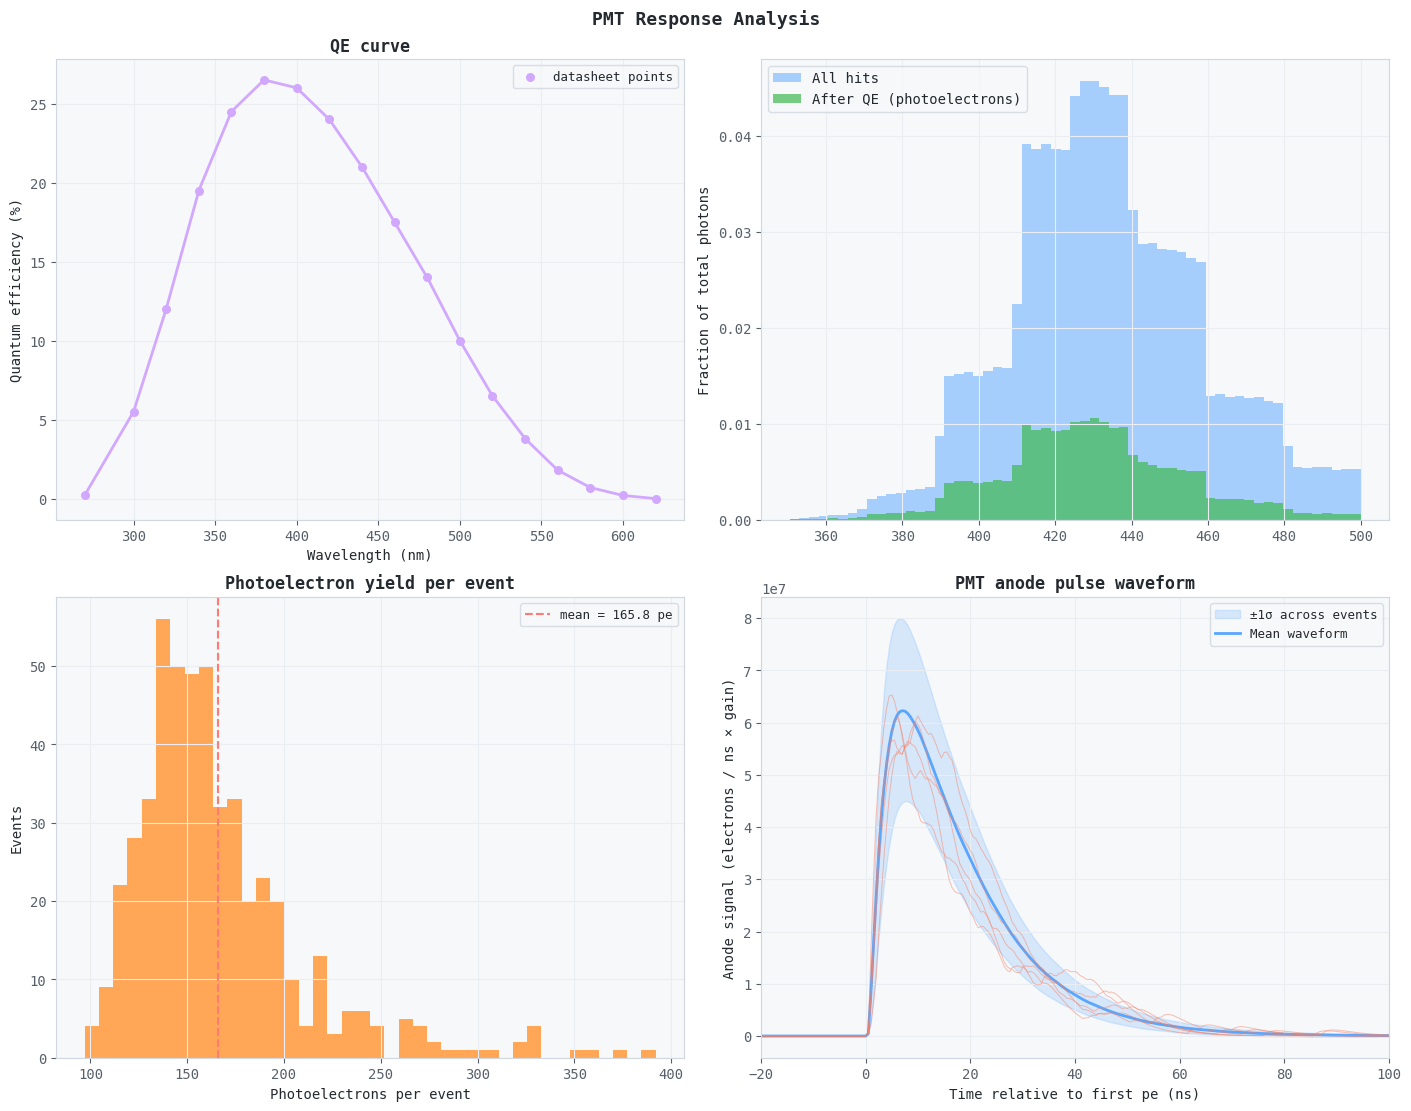

In [22]:
# ── Plots ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 11), constrained_layout=True)
fig.suptitle('PMT Response Analysis', fontsize=13, fontweight='bold')
gs  = gridspec.GridSpec(2, 2, figure=fig)

# ── 1. QE curve ──────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
wl_plot = np.linspace(QE_CURVE_NM[0], QE_CURVE_NM[-1], 400)
ax1.plot(wl_plot, _qe_interp(wl_plot) * 100,
         color='#d2a8ff', linewidth=2)
ax1.scatter(QE_CURVE_NM, QE_CURVE_FRAC * 100,
            color='#d2a8ff', s=30, zorder=5, label='datasheet points')
ax1.set_xlabel('Wavelength (nm)')
ax1.set_ylabel('Quantum efficiency (%)')
ax1.set_title('QE curve', fontweight='bold')
ax1.legend(fontsize=9)

# ── 2. Detected photon wavelength spectrum (before & after QE) ───────────────
ax2 = fig.add_subplot(gs[0, 1])
bins = np.linspace(wavelengths.min(), wavelengths.max(), 60)
total = len(wavelengths)
ax2.hist(wavelengths,          bins=bins, color='#58a6ff', alpha=0.5,
         weights=np.full(len(wavelengths),          1/total),
         label='All hits')
ax2.hist(wavelengths[pe_mask], bins=bins, color='#3fb950', alpha=0.7,
         weights=np.full(len(wavelengths[pe_mask]), 1/total),
         label='After QE (photoelectrons)')
ax2.set_ylabel('Fraction of total photons')
ax2.legend()

# ── 3. Photoelectrons per event distribution ──────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(n_pe_per_event, bins=40, color='#ffa657', edgecolor='none')
ax3.axvline(n_pe_per_event.mean(), color='#ff7b72', linestyle='--',
            linewidth=1.5, label=f'mean = {n_pe_per_event.mean():.1f} pe')
ax3.set_xlabel('Photoelectrons per event')
ax3.set_ylabel('Events')
ax3.set_title('Photoelectron yield per event', fontweight='bold')
ax3.legend(fontsize=9)

# ── 4. Mean PMT pulse waveform ± std ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
std_waveform = all_waveforms.std(axis=0)
ax4.fill_between(T_BINS,
                 mean_waveform - std_waveform,
                 mean_waveform + std_waveform,
                 color='#58a6ff', alpha=0.2, label='±1σ across events')
ax4.plot(T_BINS, mean_waveform, color='#58a6ff', linewidth=2,
         label='Mean waveform')
# Overplot a few individual events (first 5 with ≥5 pe) for context
plotted = 0
for wf, npe in zip(all_waveforms, n_pe_per_event):
    if npe >= 5:
        ax4.plot(T_BINS, wf, color='#f78166', linewidth=0.7, alpha=0.5)
        plotted += 1
    if plotted >= 5:
        break
ax4.set_xlabel('Time relative to first pe (ns)')
ax4.set_ylabel(f'Anode signal (electrons / ns × gain)')
ax4.set_title('PMT anode pulse waveform', fontweight='bold')
ax4.set_xlim(T_START_NS, min(T_END_NS, 100))
ax4.legend(fontsize=9)

plt.savefig('pmt_response.png', dpi=150, bbox_inches='tight')
print('Saved: pmt_response.png')
plt.show()


Saved: pmt_charge_spectrum.png


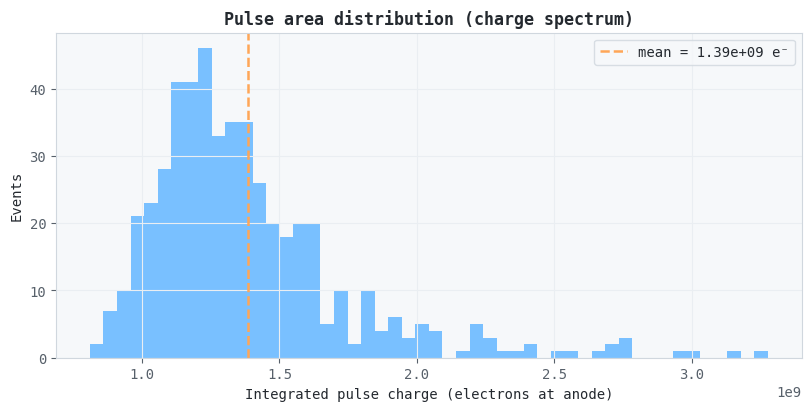


── Summary ─────────────────────────────────────────────────
  Events analysed         :      500
  Mean pe / event         :    165.8
  Std pe / event          :     44.2
  Mean integrated charge  : 1.39e+09  electrons
  Std integrated charge   : 3.69e+08  electrons
  Charge resolution (σ/μ) :    26.7%


In [23]:
# ── Integrated charge per event (the PMT 'pulse area') ──────────────────────
# Q = ∫ I(t) dt  ≈  sum(waveform) * dt
# Units: electrons (with gain already folded in, so physical electrons at anode)

charges = all_waveforms.sum(axis=1) * T_BIN_NS   # electrons per event

fig2, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)
ax.hist(charges, bins=50, color='#79c0ff', edgecolor='none')
ax.axvline(charges.mean(), color='#ffa657', linestyle='--', linewidth=1.8,
           label=f'mean = {charges.mean():.2e} e⁻')
ax.set_xlabel('Integrated pulse charge (electrons at anode)')
ax.set_ylabel('Events')
ax.set_title('Pulse area distribution (charge spectrum)', fontweight='bold')
ax.legend(fontsize=10)

plt.savefig('pmt_charge_spectrum.png', dpi=150, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
print('Saved: pmt_charge_spectrum.png')
plt.show()

print()
print('── Summary ─────────────────────────────────────────────────')
print(f'  Events analysed         : {len(charges):>8,}')
print(f'  Mean pe / event         : {n_pe_per_event.mean():>8.1f}')
print(f'  Std pe / event          : {n_pe_per_event.std():>8.1f}')
print(f'  Mean integrated charge  : {charges.mean():>8.2e}  electrons')
print(f'  Std integrated charge   : {charges.std():>8.2e}  electrons')
print(f'  Charge resolution (σ/μ) : {charges.std()/charges.mean()*100:>7.1f}%')


RC time constant τ = 1.00 ns  (R=50 Ω, C=20 pF)
Saved: pmt_voltage.png


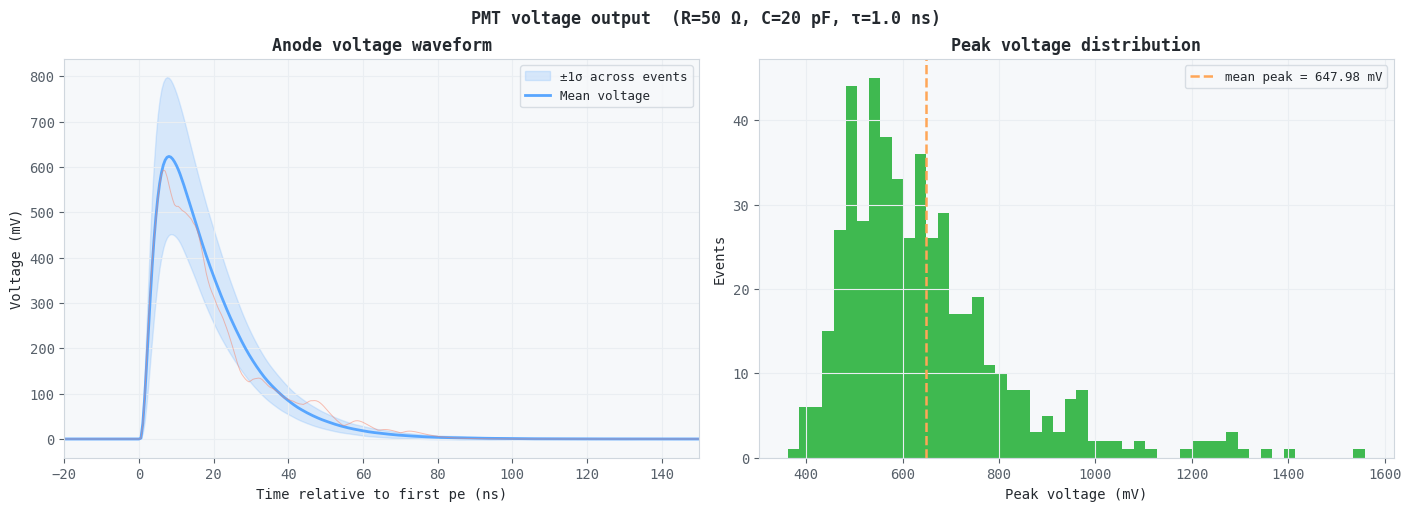


Mean peak voltage : 647.980 mV
Std peak voltage  : 177.794 mV
Voltage resolution: 27.4%


In [24]:
from scipy.signal import fftconvolve

# ── Circuit parameters ─────────────────────────────────────────────────────
# ★ Edit these to match your readout circuit ★
R_LOAD_OHM  = 50.0          # load resistance  [Ω]  — 50 Ω = standard coax
C_STRAY_F   = 20e-12        # stray capacitance [F]  — 20 pF typical
# ──────────────────────────────────────────────────────────────────────────

TAU_RC_NS = (R_LOAD_OHM * C_STRAY_F) * 1e9   # RC time constant in ns

def current_to_voltage(waveform_electrons_per_ns, t_bins):
    """
    Convert anode current waveform to voltage across R_load.

    The anode current I(t) [electrons/ns] is first converted to SI [Amperes],
    then convolved with the RC circuit impulse response h(t) = (1/τ)*exp(-t/τ).
    V(t) = (I * h) * dt   gives volts across R_load.

    Parameters
    ----------
    waveform_electrons_per_ns : array
        Output of build_waveform — already scaled by PMT_GAIN.
    t_bins : array
        Time axis in ns (uniform spacing).

    Returns
    -------
    voltage : array  [Volts]
    """
    dt_ns  = t_bins[1] - t_bins[0]
    dt_s   = dt_ns * 1e-9

    # Convert electrons/ns → Amperes
    # (electrons/ns) * (e_charge C/electron) / (1e-9 s/ns) = A
    I_amp = waveform_electrons_per_ns * e_charge / 1e-9

    # RC impulse response kernel (same time grid, causal)
    t_kernel = np.arange(0, 5 * TAU_RC_NS, dt_ns)   # 5τ is enough to decay
    if TAU_RC_NS > 0:
        h = (1.0 / (TAU_RC_NS * 1e-9)) * np.exp(-t_kernel / TAU_RC_NS)
    else:
        # Ideal resistive load (τ → 0): voltage = I * R directly
        h = np.array([1.0 / dt_s])

    # Convolve and scale by dt to keep units correct
    V_conv = fftconvolve(I_amp, h * dt_s, mode='full')[:len(t_bins)]

    # Voltage across R_load: V = I_convolved * R
    return V_conv * R_LOAD_OHM


# ── Compute per-event voltage waveforms ────────────────────────────────────────
print(f'RC time constant τ = {TAU_RC_NS:.2f} ns  '
      f'(R={R_LOAD_OHM:.0f} Ω, C={C_STRAY_F*1e12:.0f} pF)')

voltage_waveforms = np.array([
    current_to_voltage(wf, T_BINS) for wf in all_waveforms
])
mean_voltage = voltage_waveforms.mean(axis=0)
std_voltage  = voltage_waveforms.std(axis=0)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
fig.suptitle(
    f'PMT voltage output  (R={R_LOAD_OHM:.0f} Ω, '
    f'C={C_STRAY_F*1e12:.0f} pF, τ={TAU_RC_NS:.1f} ns)',
    fontsize=12, fontweight='bold',
)

# Panel 1: mean voltage waveform ± std
ax = axes[0]
ax.fill_between(T_BINS,
                (mean_voltage - std_voltage) * 1e3,
                (mean_voltage + std_voltage) * 1e3,
                color='#58a6ff', alpha=0.2, label='±1σ across events')
ax.plot(T_BINS, mean_voltage * 1e3, color='#58a6ff',
        linewidth=2, label='Mean voltage')
for wf_v, npe in zip(voltage_waveforms, n_pe_per_event):
    if npe >= 5:
        ax.plot(T_BINS, wf_v * 1e3, color='#f78166',
                linewidth=0.7, alpha=0.5)
        break   # just one example trace for context
ax.set_xlabel('Time relative to first pe (ns)')
ax.set_ylabel('Voltage (mV)')
ax.set_title('Anode voltage waveform', fontweight='bold')
ax.set_xlim(T_START_NS, min(T_END_NS, 150))
ax.legend(fontsize=9)

# Panel 2: peak voltage distribution
peak_voltages = voltage_waveforms.max(axis=1) * 1e3   # PMT pulses are negative
ax2 = axes[1]
ax2.hist(peak_voltages, bins=50, color='#3fb950', edgecolor='none')
ax2.axvline(peak_voltages.mean(), color='#ffa657', linestyle='--',
            linewidth=1.8,
            label=f'mean peak = {peak_voltages.mean():.2f} mV')
ax2.set_xlabel('Peak voltage (mV)')
ax2.set_ylabel('Events')
ax2.set_title('Peak voltage distribution', fontweight='bold')
ax2.legend(fontsize=9)

plt.savefig('pmt_voltage.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
print('Saved: pmt_voltage.png')
plt.show()

print(f'\nMean peak voltage : {peak_voltages.mean():.3f} mV')
print(f'Std peak voltage  : {peak_voltages.std():.3f} mV')
print(f'Voltage resolution: {peak_voltages.std()/abs(peak_voltages.mean())*100:.1f}%')

Saved: pmt_discriminator.png
Trigger efficiency: 413/500 events = 82.6%


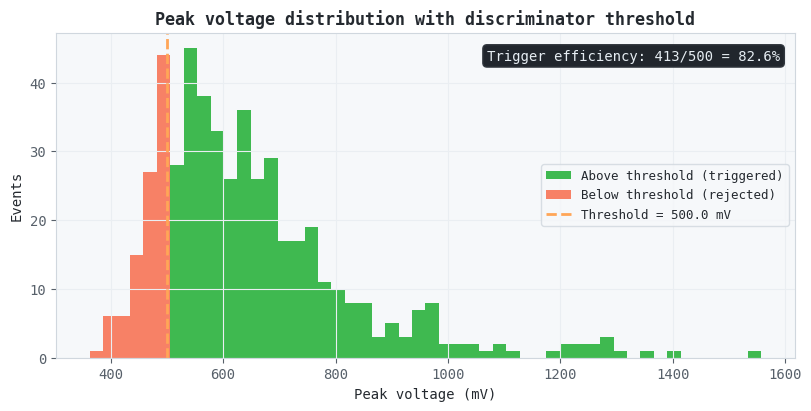

In [25]:
DISCRIMINATOR_THRESHOLD_MV = 500.0   # ★ set to your actual threshold

fig2, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

counts, bin_edges = np.histogram(peak_voltages, bins=50)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
width = bin_edges[1] - bin_edges[0]

colors = np.where(bin_centers < DISCRIMINATOR_THRESHOLD_MV, '#f78166', '#3fb950')

ax.bar(bin_centers, counts, width=width, color=colors, edgecolor='none')

ax.axvline(DISCRIMINATOR_THRESHOLD_MV, color='#ffa657',
           linestyle='--', linewidth=2)

# Dummy handles for the legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
ax.legend(handles=[
    Patch(facecolor='#3fb950', label='Above threshold (triggered)'),
    Patch(facecolor='#f78166', label='Below threshold (rejected)'),
    Line2D([0], [0], color='#ffa657', linestyle='--', linewidth=2,
           label=f'Threshold = {DISCRIMINATOR_THRESHOLD_MV:.1f} mV'),
], fontsize=9)


n_above = (peak_voltages >= DISCRIMINATOR_THRESHOLD_MV).sum()
n_total = len(peak_voltages)
efficiency = 100 * n_above / n_total

ax.set_xlabel('Peak voltage (mV)')
ax.set_ylabel('Events')
ax.set_title('Peak voltage distribution with discriminator threshold',
             fontweight='bold')

ax.text(0.98, 0.95,
        f'Trigger efficiency: {n_above}/{n_total} = {efficiency:.1f}%',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=10, color='#e6edf3',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#21262d',
                  edgecolor='#30363d'))

plt.savefig('pmt_discriminator.png', dpi=150, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
print(f'Saved: pmt_discriminator.png')
print(f'Trigger efficiency: {n_above}/{n_total} events = {efficiency:.1f}%')
plt.show()

In [37]:
# ═══════════════════════════════════════════════════════════════════════════
# ANGLE TEST — load data and validate geometry
# ═══════════════════════════════════════════════════════════════════════════
import os, glob
import uproot
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve

SWEEP_DIR = "angle_test_4000/"
#ANGLES_DEG = [0, 10, 20, 30, 40, 50, 60, 70, 80]   # angles of incidence in degrees
ANGLES_DEG = [0, 15, 30, 45, 60, 75]   # angles of incidence in degrees
# Expected path length ratio relative to θ=0  (= 1/cos θ)
# More material traversed → more photons produced
expected_path_ratio = {a: 1.0 / np.cos(np.radians(a)) for a in ANGLES_DEG}

def load_angle_file(theta):
    path = os.path.join(SWEEP_DIR, f"scoring_theta{theta}deg.root")
    if not os.path.exists(path):
        print(f'  Missing: {path}')
        return None
    with uproot.open(path) as f:
        prod   = f["PhotonsProduced"]["n_produced"].array(library="np")
        hit_ev = f["PhotonHits"]["EvID"].array(library="np")
        hit_e  = f["PhotonHits"]["energy"].array(library="np")
        hit_t  = f["PhotonHits"]["arrival_time"].array(library="np")
        ent_ev = f["MuonEntry"]["EvID"].array(library="np")   # ← add this
        y_ent  = f["MuonEntry"]["y_entry"].array(library="np")
        z_ent  = f["MuonEntry"]["z_entry"].array(library="np")

    n_events   = len(prod)
    hit_counts = np.bincount(hit_ev, minlength=n_events).astype(float)

    # Align hit_counts to the entry ntuple using EvID
    # Some events may have no entry recorded (muon missed scintillator)
    entry_hit_counts = hit_counts[ent_ev]   # index hit_counts by the entry event IDs
    return {
        'n_produced':  prod,
        'hit_counts':  hit_counts,
        'hit_energy':  hit_e,
        'hit_time':    hit_t,
        'hit_ev':      hit_ev,
        'y_entry':     y_ent,
        'z_entry':     z_ent,
        'n_events':    n_events,
        'entry_hit_counts': entry_hit_counts,
        'entry_ev': ent_ev

    }

data = {a: load_angle_file(a) for a in ANGLES_DEG}
data = {a: d for a, d in data.items() if d is not None}
print(f'Loaded {len(data)} angle files')


Loaded 6 angle files


/tmp/ipykernel_171054/449846633.py:62: RuntimeWarning: invalid value encountered in divide
  photon_sum / muon_count, np.nan).T


Saved: angle_validation.png


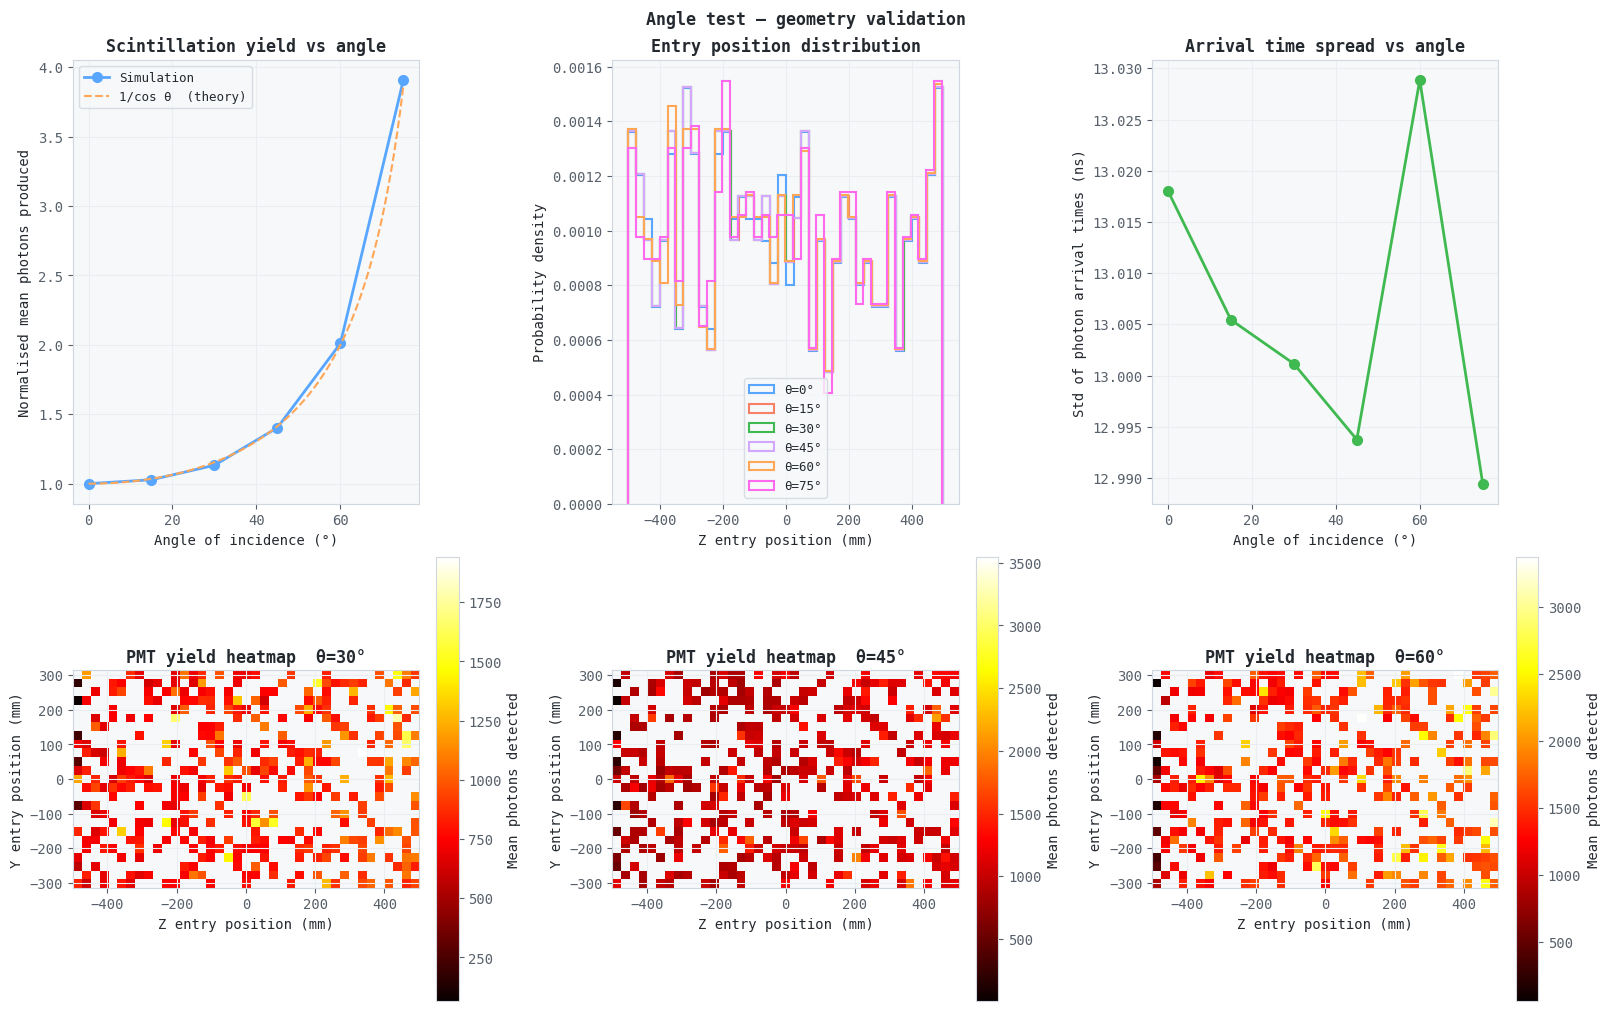

In [38]:
# ── Validation plot: check geometry is behaving correctly ────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)
fig.suptitle('Angle test — geometry validation', fontsize=12, fontweight='bold')

PALETTE = ['#58a6ff','#f78166','#3fb950','#d2a8ff','#ffa657', "#ff69ee", "#79c0ff", "#ff7b72", "#a5d6ff"]
angles_present = sorted(data.keys())

# ── Row 0, Panel 0: mean produced photons vs angle ───────────────────────────
ax = axes[0][0]
mean_prod = [data[a]['n_produced'].mean() for a in angles_present]
norm = mean_prod[0]
ax.plot(angles_present, [m / norm for m in mean_prod],
        'o-', color='#58a6ff', linewidth=2, label='Simulation')
theta_fine = np.linspace(0, max(angles_present), 200)
ax.plot(theta_fine, 1.0 / np.cos(np.radians(theta_fine)),
        '--', color='#ffa657', linewidth=1.5, label='1/cos θ  (theory)')
ax.set_xlabel('Angle of incidence (°)')
ax.set_ylabel('Normalised mean photons produced')
ax.set_title('Scintillation yield vs angle', fontweight='bold')
ax.legend(fontsize=9)

# ── Row 0, Panel 1: Z entry distribution per angle ───────────────────────────
ax = axes[0][1]
for i, a in enumerate(angles_present):
    ax.hist(data[a]['z_entry'], bins=40, histtype='step',
            color=PALETTE[i], linewidth=1.5, label=f'θ={a}°', density=True)
ax.set_xlabel('Z entry position (mm)')
ax.set_ylabel('Probability density')
ax.set_title('Entry position distribution', fontweight='bold')
ax.legend(fontsize=9)

# ── Row 0, Panel 2: photon arrival time spread vs angle ──────────────────────
ax = axes[0][2]
time_stds = [data[a]['hit_time'].std() for a in angles_present]
ax.plot(angles_present, time_stds, 'o-', color='#3fb950', linewidth=2)
ax.set_xlabel('Angle of incidence (°)')
ax.set_ylabel('Std of photon arrival times (ns)')
ax.set_title('Arrival time spread vs angle', fontweight='bold')

# ── Row 1: entry position heatmaps per angle (one per column, first 3 angles) -
n_bins_y = 25
n_bins_z = int(n_bins_y * (1000 / 628))
y_range  = [-314, 314]
z_range  = [-500, 500]

for col, a in enumerate(angles_present[2:5]):
    ax = axes[1][col]
    d  = data[a]

    photon_sum, z_edges, y_edges = np.histogram2d(
        d['z_entry'], d['y_entry'],
        bins=[n_bins_z, n_bins_y],
        range=[z_range, y_range],
        weights=d['entry_hit_counts'],
    )
    muon_count, _, _ = np.histogram2d(
        d['z_entry'], d['y_entry'],
        bins=[n_bins_z, n_bins_y],
        range=[z_range, y_range],
    )
    mean_photons = np.where(muon_count > 0,
                            photon_sum / muon_count, np.nan).T

    im = ax.imshow(
        mean_photons,
        origin='lower',
        extent=[z_range[0], z_range[1], y_range[0], y_range[1]],
        aspect='equal',
        cmap='hot',
        interpolation='nearest',
    )
    plt.colorbar(im, ax=ax, label='Mean photons detected')
    ax.set_xlabel('Z entry position (mm)')
    ax.set_ylabel('Y entry position (mm)')
    ax.set_title(f'PMT yield heatmap  θ={a}°', fontweight='bold')

plt.savefig(os.path.join(SWEEP_DIR, 'angle_validation.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
print('Saved: angle_validation.png')
plt.show()

Saved: angle_peak_voltage.png


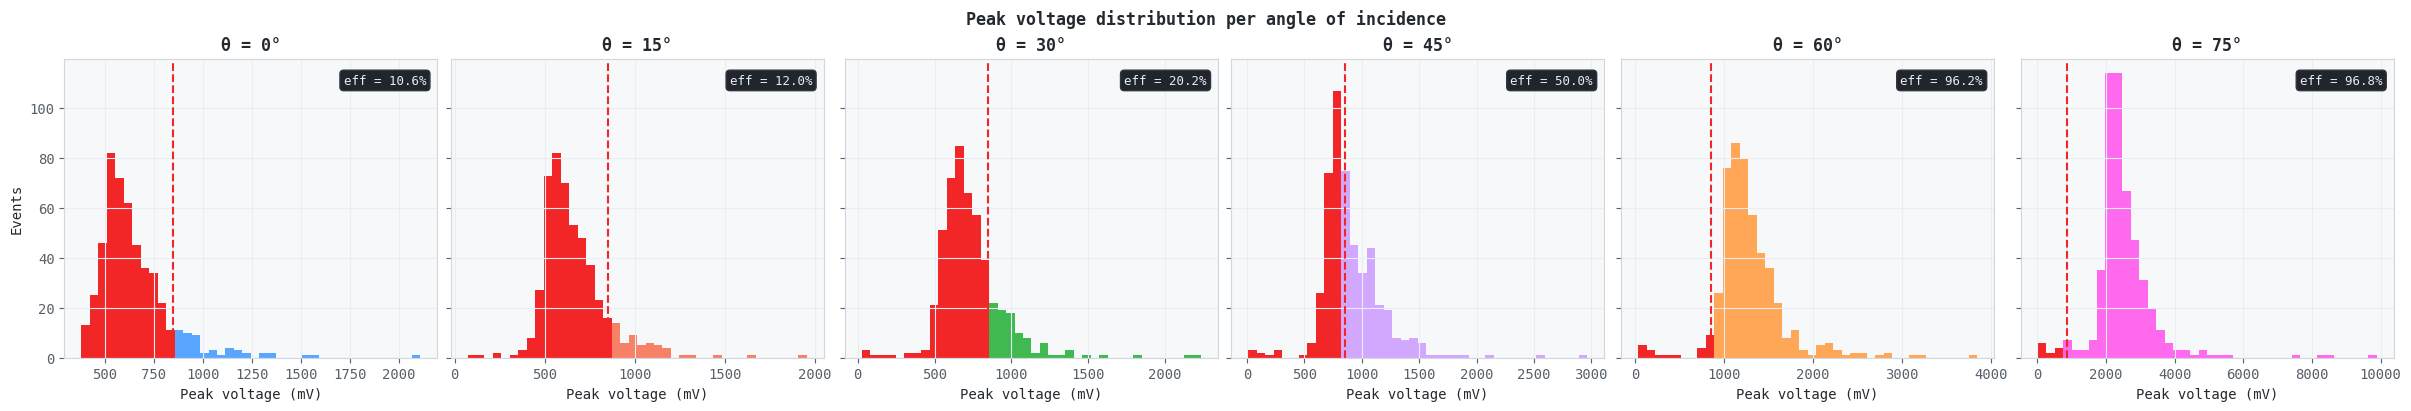

Saved: angle_mean_voltage.png


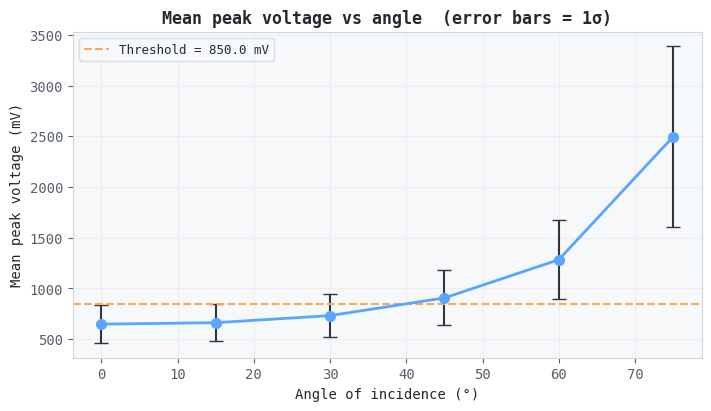

In [40]:
# ── PMT response per angle: peak voltage distributions ───────────────────────
# Reuses the PMT parameters and helper functions defined earlier in the notebook.
# Make sure you have already run those cells before this one.

rng = np.random.default_rng(seed=42)

fig, axes = plt.subplots(1, len(data), figsize=(4 * len(data), 4),
                         constrained_layout=True, sharey=True)
fig.suptitle('Peak voltage distribution per angle of incidence',
             fontsize=12, fontweight='bold')

all_peak_v = {}   # store for summary plot

for ax, (a, col) in zip(axes, zip(angles_present, PALETTE)):
    d = data[a]

    # QE filter
    wl   = photon_energy_MeV_to_wavelength_nm(d['hit_energy'])
    mask = apply_qe(wl, rng=rng)

    # Build per-event waveforms
    pe_by_ev = {}
    for ev, t, keep in zip(d['hit_ev'], d['hit_time'], mask):
        if keep:
            pe_by_ev.setdefault(int(ev), []).append(float(t))

    peak_v = []
    for ev in sorted(pe_by_ev):
        pe_t = np.array(pe_by_ev[ev])
        pe_t = pe_t - pe_t.min()
        wf   = build_waveform(pe_t, T_BINS)
        v    = current_to_voltage(wf, T_BINS)
        peak_v.append(v.max() * 1e3)

    peak_v = np.array(peak_v)
    all_peak_v[a] = peak_v

    counts, edges = np.histogram(peak_v, bins=40)
    centers = (edges[:-1] + edges[1:]) / 2
    width   = edges[1] - edges[0]
    bar_colors = np.where(centers < DISCRIMINATOR_THRESHOLD_MV,
                          "#f22626", col)
    ax.bar(centers, counts, width=width, color=bar_colors, edgecolor='none')
    ax.axvline(DISCRIMINATOR_THRESHOLD_MV, color="#f22626",
               linestyle='--', linewidth=1.5)
    eff = 100 * (peak_v >= DISCRIMINATOR_THRESHOLD_MV).mean()
    ax.set_title(f'θ = {a}°', fontweight='bold')
    ax.set_xlabel('Peak voltage (mV)')
    ax.text(0.97, 0.95, f'eff = {eff:.1f}%',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, color='#e6edf3',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#21262d',
                      edgecolor='#30363d'))

axes[0].set_ylabel('Events')
plt.savefig(os.path.join(SWEEP_DIR, 'angle_peak_voltage.png'),
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
print('Saved: angle_peak_voltage.png')
plt.show()

# ── Summary: mean peak voltage vs angle ──────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(7, 4), constrained_layout=True)
means_v = [all_peak_v[a].mean() for a in angles_present]
stds_v  = [all_peak_v[a].std()  for a in angles_present]
ax2.errorbar(angles_present, means_v, yerr=stds_v,
             fmt='o-', color='#58a6ff', ecolor='#30363d',
             elinewidth=1.5, capsize=5)
ax2.axhline(DISCRIMINATOR_THRESHOLD_MV, color='#ffa657',
            linestyle='--', linewidth=1.5,
            label=f'Threshold = {DISCRIMINATOR_THRESHOLD_MV:.1f} mV')
ax2.set_xlabel('Angle of incidence (°)')
ax2.set_ylabel('Mean peak voltage (mV)')
ax2.set_title('Mean peak voltage vs angle  (error bars = 1σ)',
              fontweight='bold')
ax2.legend(fontsize=9)
plt.savefig(os.path.join(SWEEP_DIR, 'angle_mean_voltage.png'),
            dpi=150, bbox_inches='tight', facecolor=fig2.get_facecolor())
print('Saved: angle_mean_voltage.png')
plt.show()


θ=  0°  mean= 648.01 mV  std=185.03 mV  max=2109.60 mV  CV=28.6%
θ= 15°  mean= 662.17 mV  std=183.98 mV  max=1953.07 mV  CV=27.8%
θ= 30°  mean= 731.95 mV  std=214.28 mV  max=2234.02 mV  CV=29.3%
θ= 45°  mean= 906.27 mV  std=271.14 mV  max=2964.60 mV  CV=29.9%
θ= 60°  mean=1282.83 mV  std=391.43 mV  max=3847.63 mV  CV=30.5%
θ= 75°  mean=2494.75 mV  std=889.77 mV  max=9883.19 mV  CV=35.7%
Saved: angle_scaling.png


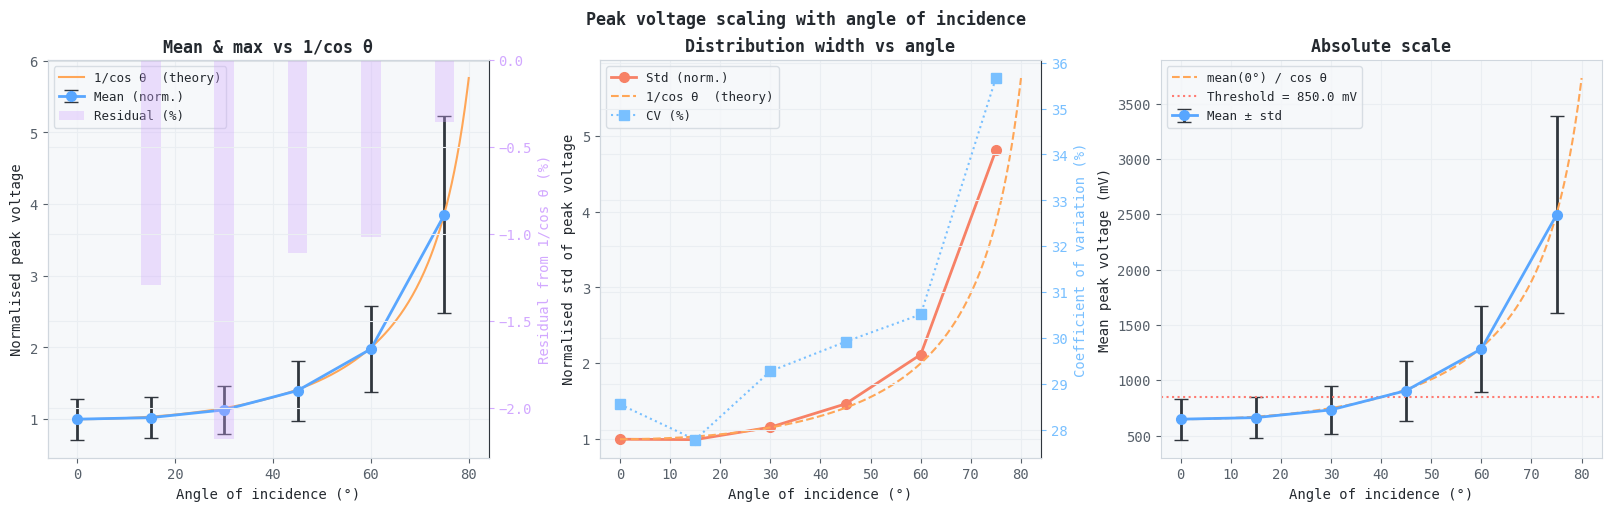

Saved: angle_distribution_fits.png


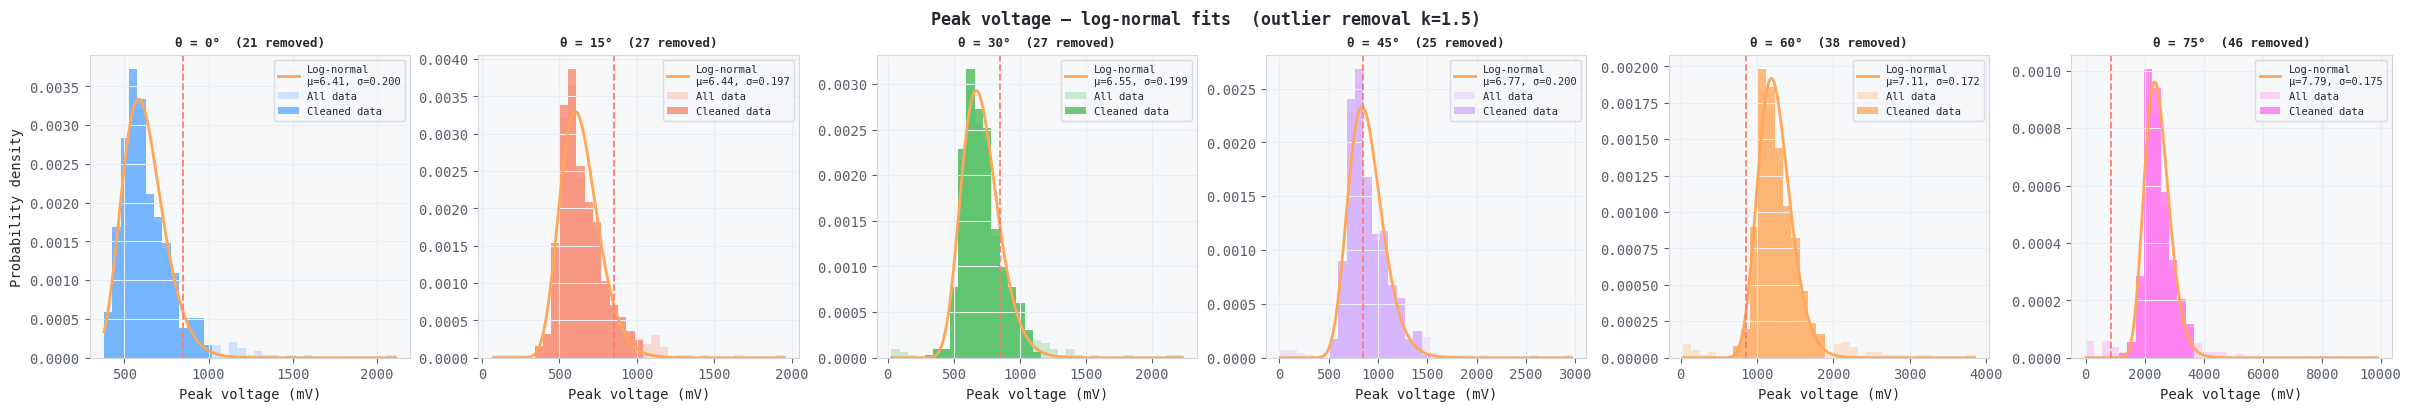

Saved: angle_fit_params.png


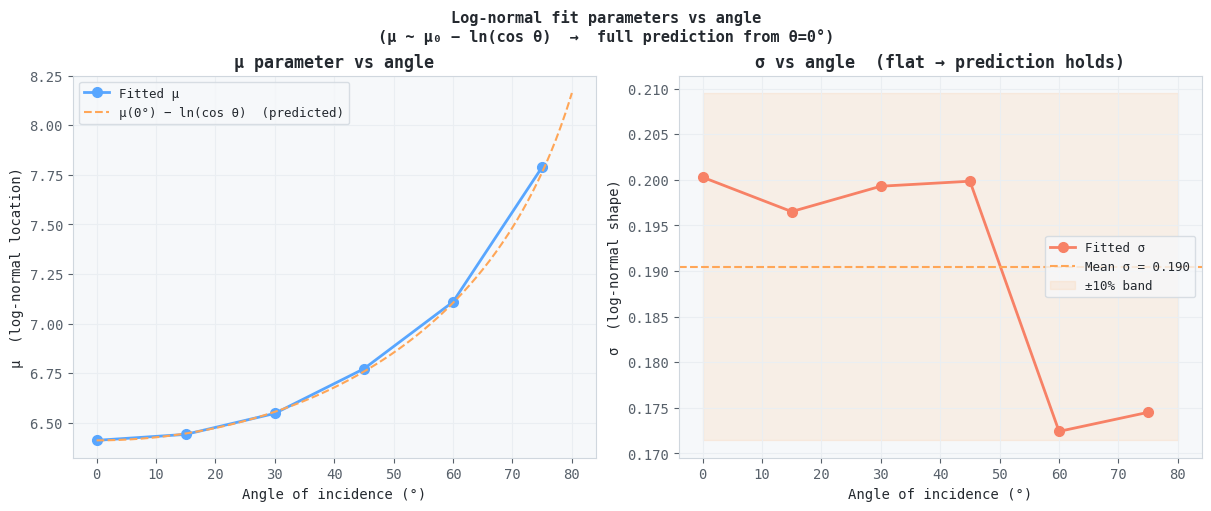


── Log-normal fit parameters  (outlier k=1.5) ───────────────
     θ     μ (fit)      μ (pred)        Δμ     σ (fit)   removed
-----------------------------------------------------------------
    0°      6.4118        6.4118    0.0000      0.2003        21
   15°      6.4418        6.4464   -0.0046      0.1965        27
   30°      6.5474        6.5556   -0.0082      0.1993        27
   45°      6.7724        6.7583    0.0141      0.1999        25
   60°      7.1098        7.1049    0.0049      0.1724        38
   75°      7.7892        7.7634    0.0258      0.1745        46

Prediction from θ=0° alone:
  μ(θ) = 6.4118 − ln(cos θ)
  σ(θ) = 0.1905  (treat as constant)

To sample the predicted distribution at angle θ:
  from scipy.stats import lognorm, np
  mu_pred    = 6.4118 - np.log(np.cos(np.radians(theta)))
  sigma_pred = 0.1905
  samples    = lognorm.rvs(s=sigma_pred, scale=np.exp(mu_pred), size=N)


In [41]:
# ═══════════════════════════════════════════════════════════════════════════
# ANGLE — peak voltage scaling + log-normal distribution parametrisation
# ═══════════════════════════════════════════════════════════════════════════
from scipy.stats import norm, lognorm
import warnings
DISCRIMINATOR_THRESHOLD_MV = 850
OUTLIER_K = 1.5  # IQR multiplier — increase to keep more tail (try 2.0–3.0)

# ── Compute peak voltages for every angle ────────────────────────────────────
rng = np.random.default_rng(seed=42)

angle_stats = {}

for a in angles_present:
    d    = data[a]
    wl   = photon_energy_MeV_to_wavelength_nm(d['hit_energy'])
    mask = apply_qe(wl, rng=rng)

    pe_by_ev = {}
    for ev, t, keep in zip(d['hit_ev'], d['hit_time'], mask):
        if keep:
            pe_by_ev.setdefault(int(ev), []).append(float(t))

    peak_v = []
    for ev in sorted(pe_by_ev):
        pe_t = np.array(pe_by_ev[ev])
        pe_t = pe_t - pe_t.min()
        wf   = build_waveform(pe_t, T_BINS)
        v    = current_to_voltage(wf, T_BINS)
        peak_v.append(v.max() * 1e3)

    peak_v = np.array(peak_v)
    angle_stats[a] = {
        'peak_v': peak_v,
        'mean':   peak_v.mean(),
        'std':    peak_v.std(),
        'max':    peak_v.max(),
        'cv':     peak_v.std() / peak_v.mean(),
    }
    print(f'θ={a:>3}°  mean={peak_v.mean():7.2f} mV  '
          f'std={peak_v.std():6.2f} mV  '
          f'max={peak_v.max():7.2f} mV  '
          f'CV={peak_v.std()/peak_v.mean()*100:.1f}%')

angles_arr = np.array(angles_present)
means_arr  = np.array([angle_stats[a]['mean'] for a in angles_present])
stds_arr   = np.array([angle_stats[a]['std']  for a in angles_present])
maxs_arr   = np.array([angle_stats[a]['max']  for a in angles_present])
cvs_arr    = np.array([angle_stats[a]['cv']   for a in angles_present])
mean0, std0, max0 = means_arr[0], stds_arr[0], maxs_arr[0]

# ── Figure 1: scaling laws ────────────────────────────────────────────────────
theta_fine = np.linspace(0, max(angles_present) + 5, 300)
cos_law    = 1.0 / np.cos(np.radians(theta_fine))

fig1, axes1 = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
fig1.suptitle('Peak voltage scaling with angle of incidence',
              fontsize=12, fontweight='bold')

# Panel 1: normalised mean & max vs 1/cosθ
ax = axes1[0]
ax.errorbar(angles_arr, means_arr / mean0, yerr=stds_arr / mean0,
            fmt='o-', color='#58a6ff', ecolor='#30363d',
            capsize=5, linewidth=2, label='Mean (norm.)')
#ax.plot(angles_arr, maxs_arr / max0,
#        's--', color='#3fb950', linewidth=1.8, label='Max (norm.)')
ax.plot(theta_fine, cos_law,
        '-', color='#ffa657', linewidth=1.5, label='1/cos θ  (theory)')
ax.set_xlabel('Angle of incidence (°)')
ax.set_ylabel('Normalised peak voltage')
ax.set_title('Mean & max vs 1/cos θ', fontweight='bold')

expected = 1.0 / np.cos(np.radians(angles_arr))
resid    = (means_arr / mean0 - expected) / expected * 100
ax_r = ax.twinx()
ax_r.bar(angles_arr, resid, width=4, color='#d2a8ff', alpha=0.35,
         label='Residual (%)')
ax_r.set_ylabel('Residual from 1/cos θ (%)', color='#d2a8ff')
ax_r.tick_params(colors='#d2a8ff')
ax_r.spines['right'].set_color('#30363d')
ax_r.axhline(0, color='#30363d', linewidth=0.8)
lines_l, labels_l = ax.get_legend_handles_labels()
lines_r, labels_r = ax_r.get_legend_handles_labels()
ax.legend(lines_l + lines_r, labels_l + labels_r, fontsize=9)

# Panel 2: normalised std + CV (unified legend)
ax = axes1[1]
ax.plot(angles_arr, stds_arr / std0,
        'o-', color='#f78166', linewidth=2, label='Std (norm.)')
ax.plot(theta_fine, cos_law,
        '--', color='#ffa657', linewidth=1.5, label='1/cos θ  (theory)')
ax.set_xlabel('Angle of incidence (°)')
ax.set_ylabel('Normalised std of peak voltage')
ax.set_title('Distribution width vs angle', fontweight='bold')

ax2r = axes1[1].twinx()
ax2r.plot(angles_arr, cvs_arr * 100,
          's:', color='#79c0ff', linewidth=1.5, label='CV (%)')
ax2r.set_ylabel('Coefficient of variation (%)', color='#79c0ff')
ax2r.tick_params(colors='#79c0ff')
ax2r.spines['right'].set_color('#30363d')
lines_l, labels_l = ax.get_legend_handles_labels()
lines_r, labels_r = ax2r.get_legend_handles_labels()
ax.legend(lines_l + lines_r, labels_l + labels_r, fontsize=9)

# Panel 3: absolute mean ± std
ax = axes1[2]
ax.errorbar(angles_arr, means_arr, yerr=stds_arr,
            fmt='o-', color='#58a6ff', ecolor='#30363d',
            capsize=5, linewidth=2, label='Mean ± std')
ax.plot(theta_fine, mean0 / np.cos(np.radians(theta_fine)),
        '--', color='#ffa657', linewidth=1.5, label='mean(0°) / cos θ')
ax.axhline(DISCRIMINATOR_THRESHOLD_MV, color='#ff7b72',
           linestyle=':', linewidth=1.5,
           label=f'Threshold = {DISCRIMINATOR_THRESHOLD_MV:.1f} mV')
ax.set_xlabel('Angle of incidence (°)')
ax.set_ylabel('Mean peak voltage (mV)')
ax.set_title('Absolute scale', fontweight='bold')
ax.legend(fontsize=9)

plt.savefig(os.path.join(SWEEP_DIR, 'angle_scaling.png'),
            dpi=150, bbox_inches='tight', facecolor=fig1.get_facecolor())
print('Saved: angle_scaling.png')
plt.show()

# ── Figure 2: log-normal fits with outlier removal ───────────────────────────
fit_params = {}

fig2, axes2 = plt.subplots(1, len(angles_present),
                            figsize=(4 * len(angles_present), 4),
                            constrained_layout=True)
fig2.suptitle(f'Peak voltage — log-normal fits  (outlier removal k={OUTLIER_K})',
              fontsize=12, fontweight='bold')

for col_idx, (a, col) in enumerate(zip(angles_present, PALETTE)):
    ax  = axes2[col_idx]
    pv  = angle_stats[a]['peak_v']

    # Outlier removal
    q1, q3   = np.percentile(pv, [25, 75])
    iqr      = q3 - q1
    lo, hi   = q1 - OUTLIER_K * iqr, q3 + OUTLIER_K * iqr
    pv_clean = pv[(pv >= lo) & (pv <= hi)]
    n_removed = len(pv) - len(pv_clean)

    # Bins over all data so outliers are still visible
    counts_all, edges = np.histogram(pv, bins=35, density=True)
    centers = (edges[:-1] + edges[1:]) / 2
    width   = edges[1] - edges[0]
    x_plot  = np.linspace(edges[0], edges[-1], 400)

    # All data (muted) + cleaned data (solid)
    ax.bar(centers, counts_all, width=width,
           color=col, alpha=0.25, edgecolor='none', label='All data')
    counts_clean, _ = np.histogram(pv_clean, bins=edges, density=True)
    ax.bar(centers, counts_clean, width=width,
           color=col, alpha=0.75, edgecolor='none', label='Cleaned data')

    # Fit log-normal on cleaned data
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        sigma_fit, loc_fit, scale_fit = lognorm.fit(pv_clean, floc=0)
    mu_ln = np.log(scale_fit)
    fit_params[a] = {'mu': mu_ln, 'sigma': sigma_fit,
                     'loc': loc_fit, 'scale': scale_fit,
                     'n_removed': n_removed}

    pdf = lognorm.pdf(x_plot, s=sigma_fit, loc=loc_fit, scale=scale_fit)
    ax.plot(x_plot, pdf, color='#ffa657', linewidth=2,
            label=f'Log-normal\nμ={mu_ln:.2f}, σ={sigma_fit:.3f}')
    ax.axvline(DISCRIMINATOR_THRESHOLD_MV, color='#ff7b72',
               linestyle='--', linewidth=1.3)
    ax.set_title(f'θ = {a}°  ({n_removed} removed)',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('Peak voltage (mV)')
    ax.legend(fontsize=7.5)

axes2[0].set_ylabel('Probability density')

plt.savefig(os.path.join(SWEEP_DIR, 'angle_distribution_fits.png'),
            dpi=150, bbox_inches='tight', facecolor=fig2.get_facecolor())
print('Saved: angle_distribution_fits.png')
plt.show()

# ── Figure 3: fit parameter evolution vs angle ───────────────────────────────
mus    = np.array([fit_params[a]['mu']    for a in angles_present])
sigmas = np.array([fit_params[a]['sigma'] for a in angles_present])

fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
fig3.suptitle('Log-normal fit parameters vs angle\n'
              '(μ ~ μ₀ − ln(cos θ)  →  full prediction from θ=0°)',
              fontsize=11, fontweight='bold')

# Panel 1: μ vs angle
ax = axes3[0]
ax.plot(angles_arr, mus, 'o-', color='#58a6ff',
        linewidth=2, label='Fitted μ')
ax.plot(theta_fine,
        mus[0] - np.log(np.cos(np.radians(theta_fine))),
        '--', color='#ffa657', linewidth=1.5,
        label='μ(0°) − ln(cos θ)  (predicted)')
ax.set_xlabel('Angle of incidence (°)')
ax.set_ylabel('μ  (log-normal location)')
ax.set_title('μ parameter vs angle', fontweight='bold')
ax.legend(fontsize=9)

# Panel 2: σ vs angle — ideally flat
ax = axes3[1]
ax.plot(angles_arr, sigmas, 'o-', color='#f78166',
        linewidth=2, label='Fitted σ')
ax.axhline(sigmas.mean(), color='#ffa657', linestyle='--',
           linewidth=1.5, label=f'Mean σ = {sigmas.mean():.3f}')
ax.fill_between(theta_fine,
                sigmas.mean() * 0.9, sigmas.mean() * 1.1,
                color='#ffa657', alpha=0.12, label='±10% band')
ax.set_xlabel('Angle of incidence (°)')
ax.set_ylabel('σ  (log-normal shape)')
ax.set_title('σ vs angle  (flat → prediction holds)', fontweight='bold')
ax.legend(fontsize=9)

plt.savefig(os.path.join(SWEEP_DIR, 'angle_fit_params.png'),
            dpi=150, bbox_inches='tight', facecolor=fig3.get_facecolor())
print('Saved: angle_fit_params.png')
plt.show()

# ── Summary printout ──────────────────────────────────────────────────────────
print()
print(f'── Log-normal fit parameters  (outlier k={OUTLIER_K}) ───────────────')
print(f'{"θ":>6}  {"μ (fit)":>10}  {"μ (pred)":>12}  '
      f'{"Δμ":>8}  {"σ (fit)":>10}  {"removed":>8}')
print('-' * 65)
for a in angles_present:
    mu_fit   = fit_params[a]['mu']
    mu_pred  = mus[0] - np.log(np.cos(np.radians(a)))
    print(f'{a:>5}°  {mu_fit:>10.4f}  {mu_pred:>12.4f}  '
          f'{mu_fit - mu_pred:>8.4f}  '
          f'{fit_params[a]["sigma"]:>10.4f}  '
          f'{fit_params[a]["n_removed"]:>8}')

print()
print('Prediction from θ=0° alone:')
print(f'  μ(θ) = {mus[0]:.4f} − ln(cos θ)')
print(f'  σ(θ) = {sigmas.mean():.4f}  (treat as constant)')
print()
print('To sample the predicted distribution at angle θ:')
print('  from scipy.stats import lognorm, np')
print(f'  mu_pred    = {mus[0]:.4f} - np.log(np.cos(np.radians(theta)))')
print(f'  sigma_pred = {sigmas.mean():.4f}')
print('  samples    = lognorm.rvs(s=sigma_pred, scale=np.exp(mu_pred), size=N)')